In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from utils import (standardize_country_name, get_continent, choropleth_continent,
choropleth_world, map_age_to_group, col_fillna, plot_dominant_choropleth, inclusion_exclusion,
standardize_vaccine_status, map_pat_status, plot_hist, plot_data_splits)

In [2]:
DATA_DIR = os.path.expanduser("~/gcs-data/Full_data")
os.listdir(DATA_DIR)

['2020_cleaned.csv',
 'Seq_metadata_2020',
 'Seq_metadata_2021',
 'Seq_metadata_2025',
 'country_continent_map.csv',
 'country_languages.csv',
 'epicov_2020_200k.csv',
 'epicov_2020_200k_cleaned.csv',
 'epicov_2021_200k.csv',
 'epicov_2021_200k_cleaned.csv',
 'epicov_2022_200k.parquet',
 'epicov_2022_200k_cleaned.parquet',
 'epicov_2023_200k.parquet',
 'epicov_2023_200k_cleaned.parquet',
 'epicov_2024_200k.parquet',
 'epicov_2024_200k_cleaned.parquet',
 'epicov_2025_200k.parquet',
 'epicov_2025_200k_cleaned.parquet',
 'models']

In [3]:
df20 = pd.read_csv(os.path.join(DATA_DIR, "epicov_2020_200k.csv"))
df21 = pd.read_csv(os.path.join(DATA_DIR, "epicov_2021_200k.csv"))
df22 = pd.read_parquet(os.path.join(DATA_DIR, "epicov_2022_200k.parquet"))
df23 = pd.read_parquet(os.path.join(DATA_DIR, "epicov_2023_200k.parquet"))
df24 = pd.read_parquet(os.path.join(DATA_DIR, "epicov_2024_200k.parquet"))
df25 = pd.read_parquet(os.path.join(DATA_DIR, "epicov_2025_200k.parquet"))
df20.shape, df21.shape, df22.shape, df23.shape, df24.shape, df25.shape

/tmp/ipykernel_24347/2948977566.py:1: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df20 = pd.read_csv(os.path.join(DATA_DIR, "epicov_2020_200k.csv"))


((200524, 18),
 (213997, 18),
 (246359, 18),
 (203488, 18),
 (200906, 18),
 (177116, 18))

In [4]:
set(df20.columns) == set(df21.columns) == set(df22.columns) == set(df23.columns) == set(df24.columns) == set(df25.columns)

True

In [5]:
def add_columns(df):
    df.rename(columns={"Accession ID": "accession_id", "Collection date": "collection_date", "Submission date": "submission_date", "Location": "location"}, inplace=True)
    # 'mixed' allows pandas to infer formats row-by-row
    df["collection_date"] = pd.to_datetime(df["collection_date"], format='mixed')
    df["submission_date"] = pd.to_datetime(df["submission_date"], format='mixed')
    df["collection_yr"] = df["collection_date"].dt.year
    df["submission_yr"] = df["submission_date"].dt.year
    # Extract Day of Year (1-365) to align Jan 2020 with Jan 2022
    df['collection_doy'] = df['collection_date'].dt.dayofyear
    df['submission_doy'] = df['submission_date'].dt.dayofyear
    return df

In [6]:
df20 = add_columns(df20)
df21 = add_columns(df21)
df22 = add_columns(df22)
df23 = add_columns(df23)
df24 = add_columns(df24)
df25 = add_columns(df25)

In [7]:
df20.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200524 entries, 0 to 200523
Data columns (total 22 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   accession_id                     200524 non-null  object        
 1   submission_date                  200524 non-null  datetime64[ns]
 2   Virus name                       200524 non-null  object        
 3   collection_date                  200524 non-null  datetime64[ns]
 4   location                         200524 non-null  object        
 5   Host                             200524 non-null  object        
 6   Additional location information  6210 non-null    object        
 7   Sampling strategy                11252 non-null   object        
 8   Gender                           200524 non-null  object        
 9   Patient age                      200519 non-null  object        
 10  Patient status                   200509 non-

## Data cleaning

For each year, we clean Patient status, Gender, Patient age etc

### 2020
#### Patient status

In [8]:
sorted(df20["Patient status"].astype(str).str.lower().unique().tolist())

['acute bronchitis',
 'acute upper respiratory infection, unspecified',
 'alive',
 'alive, no death no hospitalization',
 'ambulatory',
 'asymptomatic',
 'asymptomatic, identified as positive during preoperation investigation',
 'asymptomatic/mild',
 'asymptomatic/released',
 'aymptomatic',
 'bronchitis',
 'casualty',
 'chronic dialysis',
 'clinic',
 'community screening',
 'contact with and exposure to other communicable diseases',
 'cure',
 'cured',
 'dama',
 'dead',
 'death',
 'deceased',
 'discharged',
 'discharged after recovery',
 'domestic infection',
 'ehpad',
 'ehpad_ira',
 'epidemiology study',
 'facility quarantine',
 'fever',
 'home',
 'hopsitalized',
 'hospitalised',
 'hospitalized',
 'hospitalized (critical)',
 'hospitalized (deceased)',
 'hospitalized (intensive care unit and released)',
 'hospitalized (intensive care unit)',
 'hospitalized (live)',
 'hospitalized (mild)',
 'hospitalized (moderate)',
 'hospitalized (possible mis-c)',
 'hospitalized (released)',
 'hospita

In [9]:
unk_mask = (df20["Patient status"].astype(str).str.lower().str.startswith("u")) | (df20["Patient status"].astype(str).str.lower().isin(["nan"]))
df20.loc[unk_mask, "Patient status"] = "unknown"

#### Patient age

In [10]:
sorted(df20["Patient age"].astype(str).str.lower().unique().tolist())

['0',
 '0 - 9',
 '0-4',
 '0-9',
 '0.1',
 '0.2',
 '0.33',
 '0.4',
 '0.6',
 '0.92',
 '1',
 '1 month',
 '1 month 14 days',
 '1 months',
 '10',
 '10 - 19',
 '10 days',
 '10 months',
 '10-14',
 '10-19',
 '10-20',
 '100',
 '101',
 '102',
 '103',
 '104',
 '105',
 '107',
 '11',
 '11 months',
 '11-20',
 '110',
 '12',
 '12 months',
 '12 years 6 moths',
 '120',
 '13',
 '136',
 '14',
 '15',
 '16',
 '16-19',
 '17',
 '17 years 9 months',
 '18',
 '18 - 20',
 '18 months',
 '18 years',
 '18-20',
 '18-49',
 '19',
 '19 months',
 '19-22',
 '19.0',
 '2',
 '2 months',
 '2 weeks',
 '2 years 11 months',
 '20',
 '20 - 29',
 '20 to 29',
 '20-24',
 '20-29',
 '20-30',
 '2020-1954',
 '2020-1972',
 '2020-1979',
 '2020-1984',
 '2020-1985',
 '2020-1991',
 '2020-1994',
 '20s',
 '21',
 '21 - 30',
 '21 days',
 '21 months',
 '21-30',
 '21.0',
 '22',
 '22 months',
 '22-25',
 '23',
 '23 years',
 '24',
 '25',
 '25-28',
 '25-29',
 '26',
 '26 years',
 '27',
 '27 days',
 '27.0',
 '28',
 '28-31',
 '29',
 '3',
 '3 months',
 '30'

In [11]:
unk_mask = (df20["Patient age"].astype(str).str.lower().str.startswith("u")) | (df20["Patient age"].astype(str).str.lower().isin(["nan", "x"]))
df20.loc[unk_mask, "Patient age"] = "unknown"
sorted(df20["Patient age"].astype(str).str.lower().unique().tolist())

['0',
 '0 - 9',
 '0-4',
 '0-9',
 '0.1',
 '0.2',
 '0.33',
 '0.4',
 '0.6',
 '0.92',
 '1',
 '1 month',
 '1 month 14 days',
 '1 months',
 '10',
 '10 - 19',
 '10 days',
 '10 months',
 '10-14',
 '10-19',
 '10-20',
 '100',
 '101',
 '102',
 '103',
 '104',
 '105',
 '107',
 '11',
 '11 months',
 '11-20',
 '110',
 '12',
 '12 months',
 '12 years 6 moths',
 '120',
 '13',
 '136',
 '14',
 '15',
 '16',
 '16-19',
 '17',
 '17 years 9 months',
 '18',
 '18 - 20',
 '18 months',
 '18 years',
 '18-20',
 '18-49',
 '19',
 '19 months',
 '19-22',
 '19.0',
 '2',
 '2 months',
 '2 weeks',
 '2 years 11 months',
 '20',
 '20 - 29',
 '20 to 29',
 '20-24',
 '20-29',
 '20-30',
 '2020-1954',
 '2020-1972',
 '2020-1979',
 '2020-1984',
 '2020-1985',
 '2020-1991',
 '2020-1994',
 '20s',
 '21',
 '21 - 30',
 '21 days',
 '21 months',
 '21-30',
 '21.0',
 '22',
 '22 months',
 '22-25',
 '23',
 '23 years',
 '24',
 '25',
 '25-28',
 '25-29',
 '26',
 '26 years',
 '27',
 '27 days',
 '27.0',
 '28',
 '28-31',
 '29',
 '3',
 '3 months',
 '30'

In [12]:
gen_mask = df20["Patient age"].astype(str).str.lower().isin(["male", "female"])
df20[gen_mask]["Gender"].unique()

array(['3.0', '66.0', '69.0', '58.0', '38.0', '49.0', '57.0', '42.0',
       '75', '26', '49', '39', '44', '41', '39.0', '52.0', '22', '32',
       '75.0', '28', '34', '46', '24', '16', '50', '14', '29', '55', '21',
       '37', '35', '30', '45', '42', '63.0', '72', '29.0', '36', '27',
       '25', '65', '31', '40', '20.0', '21.0', '62', '59', '56', '57',
       '74', '58', '48', '52', '38', '79.0', '31.0', '26.0', '37.0',
       '76.0', '43', '54', '32.0', '18.0', '50.0', '27.0', '20', '18',
       '73', '63', '23', '43.0', '53', '33', '51', '47', '61', '12',
       'unknown', '3', '15', '9', '17', '60', '77', '85', '13', '66',
       '74.0', '64', '25.0', '67', '6', '54.0', '46.0', '45.0', '92',
       '30.0', '35.0'], dtype=object)

In [13]:
df20.loc[gen_mask, "Patient age"], df20.loc[gen_mask, "Gender"] = df20.loc[gen_mask, "Gender"], df20.loc[gen_mask, "Patient age"]
sorted(df20["Patient age"].astype(str).str.lower().unique().tolist())

['0',
 '0 - 9',
 '0-4',
 '0-9',
 '0.1',
 '0.2',
 '0.33',
 '0.4',
 '0.6',
 '0.92',
 '1',
 '1 month',
 '1 month 14 days',
 '1 months',
 '10',
 '10 - 19',
 '10 days',
 '10 months',
 '10-14',
 '10-19',
 '10-20',
 '100',
 '101',
 '102',
 '103',
 '104',
 '105',
 '107',
 '11',
 '11 months',
 '11-20',
 '110',
 '12',
 '12 months',
 '12 years 6 moths',
 '120',
 '13',
 '136',
 '14',
 '15',
 '16',
 '16-19',
 '17',
 '17 years 9 months',
 '18',
 '18 - 20',
 '18 months',
 '18 years',
 '18-20',
 '18-49',
 '18.0',
 '19',
 '19 months',
 '19-22',
 '19.0',
 '2',
 '2 months',
 '2 weeks',
 '2 years 11 months',
 '20',
 '20 - 29',
 '20 to 29',
 '20-24',
 '20-29',
 '20-30',
 '20.0',
 '2020-1954',
 '2020-1972',
 '2020-1979',
 '2020-1984',
 '2020-1985',
 '2020-1991',
 '2020-1994',
 '20s',
 '21',
 '21 - 30',
 '21 days',
 '21 months',
 '21-30',
 '21.0',
 '22',
 '22 months',
 '22-25',
 '23',
 '23 years',
 '24',
 '25',
 '25-28',
 '25-29',
 '25.0',
 '26',
 '26 years',
 '26.0',
 '27',
 '27 days',
 '27.0',
 '28',
 '28-

#### Gender

In [14]:
sorted(df20["Gender"].astype(str).str.lower().unique().tolist())

['0',
 '15.0',
 '16.0',
 '17.0',
 '18.0',
 '19.0',
 '20.0',
 '21.0',
 '22.0',
 '23.0',
 '24.0',
 '25.0',
 '26.0',
 '27.0',
 '28.0',
 '29.0',
 '30.0',
 '31.0',
 '32.0',
 '33.0',
 '34.0',
 '35.0',
 '36.0',
 '37.0',
 '38.0',
 '39.0',
 '40.0',
 '41.0',
 '42.0',
 '43.0',
 '44.0',
 '45.0',
 '46.0',
 '47.0',
 '48.0',
 '49.0',
 '50.0',
 '51.0',
 '52.0',
 '53.0',
 '54.0',
 '57.0',
 '58.0',
 '59.0',
 '60.0',
 '61.0',
 '62.0',
 '64.0',
 '65.0',
 '68.0',
 '69.0',
 '70.0',
 '73.0',
 '74.0',
 '76.0',
 '79.0',
 '80.0',
 '81.0',
 '84.0',
 '92.0',
 'female',
 'male',
 'unknowm',
 'unknown']

In [15]:
unk_mask = (df20["Gender"].astype(str).str.lower().str.startswith("u"))
df20.loc[unk_mask, "Gender"] = "unknown"

In [16]:
gen_mask = df20["Gender"].astype(str).str.lower().isin(["male", "female", "unknown"])
df20[~gen_mask]

,accession_id,submission_date,Virus name,collection_date,location,Host,Additional location information,Sampling strategy,Gender,Patient age,...,Passage,Specimen,Additional host information,Lineage,Clade,AA Substitutions,collection_yr,submission_yr,collection_doy,submission_doy
13002,EPI_ISL_17050087,2023-02-28,hCoV-19/Brazil/SP-IMT-CD11801/2020,2020-05-06,South America / Brazil / Sao Paulo / Sao Caeta...,Human,NaN,Female,69.0,unknown,...,Original,NaN,NaN,B.1.1.28,GR,"(NSP2_L270F,N_R203K,NSP2_E197K,N_G204R,Spike_V...",2020,2023,127,59
13003,EPI_ISL_17050050,2023-02-28,hCoV-19/Brazil/SP-IMT-CD11777/2020,2020-05-05,South America / Brazil / Sao Paulo / Sao Caeta...,Human,NaN,Female,68.0,unknown,...,Original,NaN,NaN,B.1.1.28,G,"(NSP14_V120L,NSP7_L71F,NSP12_T26I,NSP12_P323L,...",2020,2023,126,59
13004,EPI_ISL_17050049,2023-02-28,hCoV-19/Brazil/SP-IMT-CD11759/2020,2020-05-05,South America / Brazil / Sao Paulo / Sao Caeta...,Human,NaN,Female,34.0,unknown,...,Original,NaN,NaN,B.1.1.28,G,"(NSP2_L270F,NSP12_P323L,Spike_D614G,Spike_V117...",2020,2023,126,59
13005,EPI_ISL_17049966,2023-02-28,hCoV-19/Brazil/SP-IMT-CD1064/2020,2020-05-06,South America / Brazil / Sao Paulo / Sao Caeta...,Human,NaN,Male,41.0,unknown,...,Original,NaN,NaN,B.1.1.28,GR,"(N_R203K,NSP2_K500N,N_G204R,NS8_E110D,NSP12_P3...",2020,2023,127,59
13006,EPI_ISL_17049965,2023-02-28,hCoV-19/Brazil/SP-IMT-CD1072/2020,2020-05-04,South America / Brazil / Sao Paulo / Sao Caeta...,Human,NaN,Female,24.0,unknown,...,Original,NaN,NaN,B.1.1.28,GR,"(N_R203K,N_G204R,NSP12_P323L,Spike_D614G,Spike...",2020,2023,125,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198676,EPI_ISL_17050069,2023-02-28,hCoV-19/Brazil/SP-IMT-CD11773/2020,2020-06-23,South America / Brazil / Sao Paulo / Sao Caeta...,Human,NaN,Male,36.0,unknown,...,Original,NaN,NaN,B.1.1.28,G,"(NSP2_T310I,NS3_K16N,NSP7_L71F,NSP12_P323L,Spi...",2020,2023,175,59
198677,EPI_ISL_17050070,2023-02-28,hCoV-19/Brazil/SP-IMT-CD11791/2020,2020-06-23,South America / Brazil / Sao Paulo / Sao Caeta...,Human,NaN,Male,69.0,unknown,...,Original,NaN,NaN,B.1.1.33,G,"(NSP3_P1787S,NSP3_S1206L,NSP3_E81D,NSP12_A400T...",2020,2023,175,59
198678,EPI_ISL_17050106,2023-02-28,hCoV-19/Brazil/SP-IMT-CD11832/2020,2020-06-23,South America / Brazil / Sao Paulo / Sao Caeta...,Human,NaN,Male,15.0,unknown,...,Original,NaN,NaN,B.1.1.33,GR,"(N_R203K,N_G204R,NSP12_P323L,NSP4_L264F,Spike_...",2020,2023,175,59
198679,EPI_ISL_17050107,2023-02-28,hCoV-19/Brazil/SP-IMT-CD11836/2020,2020-06-23,South America / Brazil / Sao Paulo / Sao Caeta...,Human,NaN,Female,30.0,unknown,...,Original,NaN,NaN,B.1.1.28,GR,"(N_R203K,N_G204R,NSP12_P323L,Spike_D614G,Spike...",2020,2023,175,59


In [17]:
age_unk_mask = (df20["Patient age"].astype(str).str.lower() == "unknown") & (~gen_mask)
df20.loc[age_unk_mask, "Gender"], df20.loc[age_unk_mask, "Patient age"], df20.loc[age_unk_mask, "Sampling strategy"] = df20.loc[age_unk_mask, "Sampling strategy"], df20.loc[age_unk_mask, "Gender"], df20.loc[age_unk_mask, "Patient age"]

In [18]:
unk_mask = df20["Gender"].astype(str).str.lower().isin(["male", "female"])
df20.loc[~unk_mask, "Gender"] = "unknown"
sorted(df20["Gender"].astype(str).str.lower().unique().tolist())

['female', 'male', 'unknown']

In [19]:
yr = 2020
df = eval(f"df{str(yr)[-2:]}")
print(f"*************************** Year: {yr} ***************************")
_, split20 = inclusion_exclusion(df)

*************************** Year: 2020 ***************************
Exclusion 1: Removed 183410 samples with 'Unknown' patient status.
Exclusion 2: Removed 13844 samples with ambiguous patient status.
Exclusion 3: Removed 0 samples with missing patient status.
Inclusion 1: Included 1152 samples with severe patient status.
Inclusion 2: Included 699 samples with mild patient status.
Total samples after applying inclusion/exclusion criteria: 1851 (Removed 197254 samples out of 200524)
Percentage of meaningful samples: 0.92%


In [20]:
# Save the updated dataframes
df20.to_csv(os.path.join(DATA_DIR, "epicov_2020_200k_cleaned.csv"), index=False)

### 2021
#### Patient status

In [21]:
sorted(df21["Patient status"].astype(str).str.lower().unique().tolist())

['42.0',
 '45.0',
 '51.0',
 '55.0',
 '68.0',
 'alive',
 'alive, no death no hospitalization',
 'ambulatory',
 'asymptomatic',
 'asymtomatic',
 'cas contact',
 'cas suspect',
 'community surveillance',
 'confirmed sad',
 'confirmed sad-sad',
 'confirmed scte',
 'contact',
 'contact surveillance',
 'contact-sad',
 'cure',
 'dead',
 'dead, hospitalized',
 'death',
 'decease',
 'deceased',
 'discharged',
 'discharged alive',
 'etude',
 'exitus',
 'fatal',
 'flu-like symptoms',
 'home',
 'hopspitalized',
 'hospitalised',
 'hospitalized',
 'hospitalized, no clinical signs',
 'hospitilized',
 'hospitlalized',
 'inpatient',
 'live',
 'live (moderate disease)',
 'live, hospitalized',
 'live, not hospitalized',
 'live, not hospitalized.',
 'live.',
 'live. not hospitalized',
 'mild',
 'mild clinical signs',
 'mild clinical signs without hospitalization',
 'mild clinical signs without hospitalization. distorted ability to smell',
 'mild clinical signs without hospitalization. distorted ability to

In [22]:
unk_mask = (df21["Patient status"].astype(str).str.lower().str.startswith("u")) | (df21["Patient status"].astype(str).str.lower().isin(["nan"]))
df21.loc[unk_mask, "Patient status"] = "unknown"

In [23]:
def isnum(x):
    try:
        float(x)
        return True
    except:
        return False

In [24]:
float_mask = df21["Patient status"].astype(str).apply(isnum)
df21[float_mask][["accession_id", "Patient status", "Gender", "Patient age", "Sampling strategy"]]

,accession_id,Patient status,Gender,Patient age,Sampling strategy
134056,EPI_ISL_1039695,45.0,Male,Male,NaN
134057,EPI_ISL_1039694,55.0,Male,Male,NaN
134058,EPI_ISL_1039693,42.0,Female,Female,NaN
134059,EPI_ISL_1039692,68.0,Male,Female,NaN
134060,EPI_ISL_1039691,51.0,Male,Male,NaN


In [25]:
df21.loc[float_mask, "Patient status"], df21.loc[float_mask, "Patient age"] = df21.loc[float_mask, "Patient age"], df21.loc[float_mask, "Patient status"]
stat_gen_mask = float_mask & (df21["Patient status"] == df21["Gender"])
df21[stat_gen_mask][["accession_id", "Patient status", "Gender", "Patient age", "Sampling strategy"]]

,accession_id,Patient status,Gender,Patient age,Sampling strategy
134056,EPI_ISL_1039695,Male,Male,45.0,NaN
134057,EPI_ISL_1039694,Male,Male,55.0,NaN
134058,EPI_ISL_1039693,Female,Female,42.0,NaN
134060,EPI_ISL_1039691,Male,Male,51.0,NaN


In [26]:
df21.loc[stat_gen_mask, "Patient status"] = "unknown"

#### Patient age

In [27]:
sorted(df21["Patient age"].astype(str).str.lower().unique().tolist())

['-',
 '0',
 '0 - 18',
 '0 - 9',
 '0 month',
 '0 months',
 '0 to 9',
 '0-4',
 '0-9',
 '0.16',
 '0.17',
 '0.41',
 '0.42',
 '0.8',
 '0.91',
 '1',
 '1 m',
 '1 yr',
 '1.33',
 '1.66',
 '10',
 '10 - 19',
 '10 months',
 '10 to 19',
 '10-14',
 '10-19',
 '10.0',
 '100',
 '100.0',
 '101',
 '102',
 '103',
 '104',
 '105',
 '109',
 '11',
 '11 months',
 '11-20',
 '11.0',
 '117',
 '119',
 '12',
 '12 days',
 '12 months',
 '12-55',
 '12.0',
 '120',
 '121',
 '12y to 55y',
 '13',
 '13 months',
 '13.0',
 '14',
 '14 months',
 '14.0',
 '15',
 '15 months',
 '15-19',
 '15.0',
 '16',
 '16 months',
 '16, white, not hispanic or latino',
 '16-19',
 '16.0',
 '17',
 '17, hispanic or latino',
 '17.0',
 '18',
 '18 months',
 '18.0',
 '19',
 '19 days',
 '19-22',
 '19.0',
 '2',
 '2 months',
 '2.0',
 '20',
 '20 - 29',
 '20 months',
 '20 to 29',
 '20, white, hispanic or latino',
 '20, white, not hispanic or latino',
 '20-24',
 '20-29',
 '20.0',
 '2020-1977',
 '21',
 '21 months',
 '21- 30',
 '21-30',
 '21.0',
 '22',
 '22, 

In [28]:
df21["Patient age"] = df21["Patient age"].astype(str).str.lower().str.replace("unknown", "")
sorted(df21["Patient age"].astype(str).str.lower().unique().tolist())

['',
 '-',
 '0',
 '0 - 18',
 '0 - 9',
 '0 month',
 '0 months',
 '0 to 9',
 '0-4',
 '0-9',
 '0.16',
 '0.17',
 '0.41',
 '0.42',
 '0.8',
 '0.91',
 '1',
 '1 m',
 '1 yr',
 '1.33',
 '1.66',
 '10',
 '10 - 19',
 '10 months',
 '10 to 19',
 '10-14',
 '10-19',
 '10.0',
 '100',
 '100.0',
 '101',
 '102',
 '103',
 '104',
 '105',
 '109',
 '11',
 '11 months',
 '11-20',
 '11.0',
 '117',
 '119',
 '12',
 '12 days',
 '12 months',
 '12-55',
 '12.0',
 '120',
 '121',
 '12y to 55y',
 '13',
 '13 months',
 '13.0',
 '14',
 '14 months',
 '14.0',
 '15',
 '15 months',
 '15-19',
 '15.0',
 '16',
 '16 months',
 '16, white, not hispanic or latino',
 '16-19',
 '16.0',
 '17',
 '17, hispanic or latino',
 '17.0',
 '18',
 '18 months',
 '18.0',
 '19',
 '19 days',
 '19-22',
 '19.0',
 '2',
 '2 months',
 '2.0',
 '20',
 '20 - 29',
 '20 months',
 '20 to 29',
 '20, white, hispanic or latino',
 '20, white, not hispanic or latino',
 '20-24',
 '20-29',
 '20.0',
 '2020-1977',
 '21',
 '21 months',
 '21- 30',
 '21-30',
 '21.0',
 '22',
 

In [29]:
unk_mask = (df21["Patient age"].astype(str).str.lower().str.startswith("u")) | (df21["Patient age"].astype(str).str.lower().isin(["nan", "nf", "np", "", "-"]))
df21.loc[unk_mask, "Patient age"] = "unknown"

In [30]:
gen_mask = df21["Patient age"].astype(str).str.lower().isin(["male", "female"])
df21.loc[gen_mask, "Patient age"], df21.loc[gen_mask, "Gender"] = df21.loc[gen_mask, "Gender"], df21.loc[gen_mask, "Patient age"]

In [31]:
sorted(df21["Patient age"].astype(str).str.lower().unique().tolist())

['0',
 '0 - 18',
 '0 - 9',
 '0 month',
 '0 months',
 '0 to 9',
 '0-4',
 '0-9',
 '0.16',
 '0.17',
 '0.41',
 '0.42',
 '0.8',
 '0.91',
 '1',
 '1 m',
 '1 yr',
 '1.33',
 '1.66',
 '10',
 '10 - 19',
 '10 months',
 '10 to 19',
 '10-14',
 '10-19',
 '10.0',
 '100',
 '100.0',
 '101',
 '102',
 '103',
 '104',
 '105',
 '109',
 '11',
 '11 months',
 '11-20',
 '11.0',
 '117',
 '119',
 '12',
 '12 days',
 '12 months',
 '12-55',
 '12.0',
 '120',
 '121',
 '12y to 55y',
 '13',
 '13 months',
 '13.0',
 '14',
 '14 months',
 '14.0',
 '15',
 '15 months',
 '15-19',
 '15.0',
 '16',
 '16 months',
 '16, white, not hispanic or latino',
 '16-19',
 '16.0',
 '17',
 '17, hispanic or latino',
 '17.0',
 '18',
 '18 months',
 '18.0',
 '19',
 '19 days',
 '19-22',
 '19.0',
 '2',
 '2 months',
 '2.0',
 '20',
 '20 - 29',
 '20 months',
 '20 to 29',
 '20, white, hispanic or latino',
 '20, white, not hispanic or latino',
 '20-24',
 '20-29',
 '20.0',
 '2020-1977',
 '21',
 '21 months',
 '21- 30',
 '21-30',
 '21.0',
 '22',
 '22, white,

#### Gender

In [32]:
sorted(df21["Gender"].astype(str).str.lower().unique().tolist())

['12.0',
 '15.0',
 '18.0',
 '21.0',
 '22.0',
 '23.0',
 '24.0',
 '25.0',
 '26.0',
 '27.0',
 '28.0',
 '29',
 '29.0',
 '30.0',
 '31.0',
 '32.0',
 '33.0',
 '35.0',
 '37',
 '38.0',
 '39.0',
 '40.0',
 '41.0',
 '42.0',
 '44.0',
 '46.0',
 '48.0',
 '49.0',
 '51.0',
 '52.0',
 '53.0',
 '54.0',
 '55.0',
 '56',
 '56.0',
 '57',
 '57.0',
 '58.0',
 '59',
 '59.0',
 '63.0',
 '64.0',
 '66.0',
 '68.0',
 '70.0',
 '71.0',
 '72.0',
 '76.0',
 '77.0',
 '79.0',
 '80.0',
 '82.0',
 '85.0',
 'female',
 'male',
 'nan',
 'unknowm',
 'unknown']

In [33]:
unk_mask = df21["Gender"].astype(str).str.lower().str.startswith("u") | (df21["Gender"].astype(str).str.lower().isin(["nan"]))
df21.loc[unk_mask, "Gender"] = "unknown"

In [34]:
sorted(df21["Gender"].astype(str).str.lower().unique().tolist())

['12.0',
 '15.0',
 '18.0',
 '21.0',
 '22.0',
 '23.0',
 '24.0',
 '25.0',
 '26.0',
 '27.0',
 '28.0',
 '29',
 '29.0',
 '30.0',
 '31.0',
 '32.0',
 '33.0',
 '35.0',
 '37',
 '38.0',
 '39.0',
 '40.0',
 '41.0',
 '42.0',
 '44.0',
 '46.0',
 '48.0',
 '49.0',
 '51.0',
 '52.0',
 '53.0',
 '54.0',
 '55.0',
 '56',
 '56.0',
 '57',
 '57.0',
 '58.0',
 '59',
 '59.0',
 '63.0',
 '64.0',
 '66.0',
 '68.0',
 '70.0',
 '71.0',
 '72.0',
 '76.0',
 '77.0',
 '79.0',
 '80.0',
 '82.0',
 '85.0',
 'female',
 'male',
 'unknown']

In [35]:
float_mask = df21["Gender"].astype(str).apply(isnum)
df21.loc[float_mask, "Patient age"], df21.loc[float_mask, "Gender"] = df21.loc[float_mask, "Gender"], df21.loc[float_mask, "Patient age"]

In [36]:
sorted(df21["Gender"].astype(str).str.lower().unique().tolist())

['female', 'male', 'unknown']

In [37]:
yr = 2021
df = eval(f"df{str(yr)[-2:]}")
print(f"*************************** Year: {yr} ***************************")
_, split21 = inclusion_exclusion(df, yr)

*************************** Year: 2021 ***************************
Exclusion 1: Removed 203850 samples with 'Unknown' patient status.
Exclusion 2: Removed 7252 samples with ambiguous patient status.
Exclusion 3: Removed 0 samples with missing patient status.
Inclusion 1: Included 371 samples with severe patient status.
Inclusion 2: Included 1082 samples with mild patient status.
Total samples after applying inclusion/exclusion criteria: 1453 (Removed 211102 samples out of 213997)
Percentage of meaningful samples: 0.68%


In [38]:
# Save the updated dataframe
df21.to_csv(os.path.join(DATA_DIR, "epicov_2021_200k_cleaned.csv"), index=False)

### 2022

#### Patient status

In [39]:
sorted(df22["Patient status"].astype(str).str.lower().unique().tolist())

['---',
 'active',
 'admitted for two days with covid pneumonia',
 'alive',
 'ambulatory',
 'aspirado',
 'assymptomatic',
 'asymptomatic',
 'asymptomatic - ambulatory',
 'asymtomatic',
 'cure',
 'dead',
 'deceased',
 'deceased (brought in dead)',
 'die',
 'discharged',
 'healthcare worker',
 'hisopado',
 'home isolated',
 'hospitalised',
 'hospitalized',
 'hospitalized, released',
 'hospitalized, severe',
 'hotel isolation',
 'inpatient',
 'intensive care',
 'live',
 'live - intensive care unit',
 'mild',
 'mild disease',
 'mild infection',
 'missing',
 'moderate',
 'non-hospitalized',
 'not vaccinated',
 'outpatient',
 'paucisymptomatic',
 'quarantine',
 'recovered',
 'released',
 'released, live',
 'severe',
 'stable',
 'suspect',
 'symptomatic',
 'symptomatic - ambulatory',
 'unknow',
 'unknown',
 'unknwon',
 'unkown',
 'vaccinated',
 'voyageur sortant']

In [40]:
unk_mask = (df22["Patient status"].astype(str).str.lower().str.startswith("u")) | (df22["Patient status"].astype(str).str.lower().isin(["---"]))
df22.loc[unk_mask, "Patient status"] = "unknown"

In [41]:
add_host_mask = df22["Patient status"].astype(str).str.lower().isin(["voyageur sortant"])
df22.loc[add_host_mask, "Additional host information"] = df22.loc[add_host_mask, "Patient status"]
df22.loc[add_host_mask, "Patient status"] = "unknown"

### Patient age

In [42]:
sorted(df22["Patient age"].astype(str).str.lower().unique().tolist())

['-',
 '---',
 '-1',
 '-4',
 '0',
 '0 - 9',
 '0 months',
 '0 years',
 '0,5',
 '0-4',
 '0-9',
 '0.0',
 '0.3',
 '04',
 '1',
 '1 month',
 '1.0',
 '10',
 '10 - 19',
 '10 months',
 '10 years',
 '10-14',
 '10-19',
 '10-20',
 '10.0',
 '100',
 '101',
 '102',
 '105',
 '10m',
 '11',
 '11 months',
 '11-20',
 '11.0',
 '116',
 '12',
 '12.0',
 '12.00',
 '120',
 '121',
 '122',
 '13',
 '13 years',
 '13.0',
 '14',
 '14.0',
 '15',
 '15-19',
 '15.0',
 '15.00',
 '15d',
 '16',
 '16 days',
 '16 months',
 '16 years',
 '16-19',
 '16.0',
 '17',
 '17 months',
 '17.0',
 '17m',
 '18',
 '18 months',
 '18-64',
 '18.0',
 '19',
 '19 months',
 '19 years',
 '19-22',
 '19.0',
 '19.00',
 '1m',
 '2',
 '2 months',
 '2 weeks',
 '2 years 9 months',
 '2.0',
 '20',
 '20 - 29',
 '20 years',
 '20-24',
 '20-29',
 '20-30',
 '20.0',
 '21',
 '21 months',
 '21 years',
 '21-30',
 '21.0',
 '22',
 '22 years',
 '22-25',
 '22.0',
 '23',
 '23 days',
 '23 months',
 '23 years',
 '23.0',
 '24',
 '24 years',
 '24.0',
 '24.00',
 '25',
 '25-28',

In [43]:
unk_mask = (df22["Patient age"].astype(str).str.lower().str.startswith("u")) | (df22["Patient age"].astype(str).str.lower().str.startswith("n")) | (df22["Patient age"].astype(str).str.lower().isin(["-", "---", "?", "missing"]))
df22.loc[unk_mask, "Patient age"] = "unknown"

In [44]:
gen_mask = df22["Patient age"].astype(str).str.lower().isin(["male", "female"])
df22.loc[gen_mask, "Patient age"], df22.loc[gen_mask, "Gender"] = df22.loc[gen_mask, "Gender"], df22.loc[gen_mask, "Patient age"]

#### Gender

In [45]:
sorted(df22["Gender"].astype(str).str.lower().unique().tolist())

['---',
 '0',
 '28.0',
 '31',
 '33.0',
 '5',
 'female',
 'male',
 'nasopharyngeal swab”',
 'none',
 'unknown']

In [46]:
gen_mask = df22["Gender"].astype(str).str.lower().isin(["male", "unknown", "female"])
df22[~gen_mask][["accession_id", "Patient status", "Patient age", "Gender", "Sampling strategy"]]

,accession_id,Patient status,Patient age,Gender,Sampling strategy
2111,EPI_ISL_8903084,unknown,0,0,None
2113,EPI_ISL_8903007,unknown,0,0,None
2114,EPI_ISL_8903003,unknown,0,0,None
16944,EPI_ISL_13145748,unknown,unknown,---,Sentinel surveillance (SARI)
16950,EPI_ISL_13145750,unknown,unknown,---,Sentinel surveillance (SARI)
16951,EPI_ISL_13145749,unknown,unknown,---,Sentinel surveillance (SARI)
16957,EPI_ISL_13145751,unknown,unknown,---,Sentinel surveillance (SARI)
16964,EPI_ISL_13145743,unknown,unknown,---,Sentinel surveillance (SARI)
16973,EPI_ISL_13145744,unknown,unknown,---,Sentinel surveillance (SARI)
17453,EPI_ISL_13145747,unknown,unknown,---,Sentinel surveillance (SARI)


In [47]:
float_mask = df22["Gender"].astype(str).apply(isnum)
df22[float_mask][["accession_id", "Patient status", "Patient age", "Gender", "Sampling strategy"]]

,accession_id,Patient status,Patient age,Gender,Sampling strategy
2111,EPI_ISL_8903084,unknown,0,0,None
2113,EPI_ISL_8903007,unknown,0,0,None
2114,EPI_ISL_8903003,unknown,0,0,None
34385,EPI_ISL_8902996,unknown,0,0,None
34386,EPI_ISL_8903001,unknown,0,0,None
34470,EPI_ISL_8902987,unknown,0,0,None
45715,EPI_ISL_8903000,unknown,0,0,None
117087,EPI_ISL_8903006,unknown,0,0,None
118698,EPI_ISL_8769431,unknown,unknown,31,None
121278,EPI_ISL_8903005,unknown,0,0,None


In [48]:
df22.loc[float_mask, "Patient age"] = df22.loc[float_mask, "Gender"]

In [49]:
none_mask = df22["Gender"].astype(str).str.lower().isin(["none"])
df22.loc[none_mask, "Gender"] = "unknown"

In [50]:
samp_strat_mask = df22["Gender"].astype(str).str.lower().str.startswith("naso")
df22.loc[samp_strat_mask, "Sampling strategy"] = df22.loc[samp_strat_mask, "Gender"]

In [51]:
df22[~gen_mask][["accession_id", "Patient status", "Patient age", "Gender", "Sampling strategy"]]

,accession_id,Patient status,Patient age,Gender,Sampling strategy
2111,EPI_ISL_8903084,unknown,0,0,None
2113,EPI_ISL_8903007,unknown,0,0,None
2114,EPI_ISL_8903003,unknown,0,0,None
16944,EPI_ISL_13145748,unknown,unknown,---,Sentinel surveillance (SARI)
16950,EPI_ISL_13145750,unknown,unknown,---,Sentinel surveillance (SARI)
16951,EPI_ISL_13145749,unknown,unknown,---,Sentinel surveillance (SARI)
16957,EPI_ISL_13145751,unknown,unknown,---,Sentinel surveillance (SARI)
16964,EPI_ISL_13145743,unknown,unknown,---,Sentinel surveillance (SARI)
16973,EPI_ISL_13145744,unknown,unknown,---,Sentinel surveillance (SARI)
17453,EPI_ISL_13145747,unknown,unknown,---,Sentinel surveillance (SARI)


In [52]:
df22.loc[~gen_mask, "Gender"] = "unknown"

In [53]:
yr = 2022
df = eval(f"df{str(yr)[-2:]}")
print(f"*************************** Year: {yr} ***************************")
_, split22 = inclusion_exclusion(df, yr)

*************************** Year: 2022 ***************************
Exclusion 1: Removed 234849 samples with 'Unknown' patient status.
Exclusion 2: Removed 9553 samples with ambiguous patient status.
Exclusion 3: Removed 0 samples with missing patient status.
Inclusion 1: Included 124 samples with severe patient status.
Inclusion 2: Included 1270 samples with mild patient status.
Total samples after applying inclusion/exclusion criteria: 1394 (Removed 244402 samples out of 246359)
Percentage of meaningful samples: 0.57%


In [54]:
# Save the updated dataframes
df22.to_parquet(os.path.join(DATA_DIR, "epicov_2022_200k_cleaned.parquet"), index=False)

### 2023
#### Patient status

In [55]:
sorted(df23["Patient status"].astype(str).str.lower().unique().tolist())

['alive',
 'ambulatory',
 'asymptomatic',
 'asymptomatic; recovered',
 'cure',
 'death',
 'deceased',
 'deceased (bid)',
 'healthcare worker',
 'home isolation',
 'hospital cases',
 'hospitalizado',
 'hospitalized',
 'hospitalized, live',
 'inpatient',
 'live',
 'male',
 'mild',
 'mild; lost at follow-up',
 'mild; recovered',
 'missing',
 'non-hospitalized',
 'not hospitalized',
 'nurse-house',
 'out-patient',
 'outpatient',
 'paucisymptomatic',
 'paucisymptomatic; recovered',
 'recovered',
 'recovered (no symptoms)',
 'released',
 'released, live',
 'severe',
 'severe; recovered',
 'symptomatic',
 'unknow',
 'unknown',
 'unkonwn',
 'unkown']

In [56]:
unk_mask = (df23["Patient status"].astype(str).str.lower().str.startswith("u")) | (df23["Patient status"].astype(str).str.lower().isin(["missing"]))
df23.loc[unk_mask, "Patient status"] = "unknown"

In [57]:
sorted(df23["Patient status"].astype(str).str.lower().unique().tolist())

['alive',
 'ambulatory',
 'asymptomatic',
 'asymptomatic; recovered',
 'cure',
 'death',
 'deceased',
 'deceased (bid)',
 'healthcare worker',
 'home isolation',
 'hospital cases',
 'hospitalizado',
 'hospitalized',
 'hospitalized, live',
 'inpatient',
 'live',
 'male',
 'mild',
 'mild; lost at follow-up',
 'mild; recovered',
 'non-hospitalized',
 'not hospitalized',
 'nurse-house',
 'out-patient',
 'outpatient',
 'paucisymptomatic',
 'paucisymptomatic; recovered',
 'recovered',
 'recovered (no symptoms)',
 'released',
 'released, live',
 'severe',
 'severe; recovered',
 'symptomatic',
 'unknown']

In [58]:
gen_mask = df23["Patient status"].astype(str).str.lower().isin(["male"])
df23[gen_mask]

,accession_id,submission_date,Virus name,collection_date,location,Host,Additional location information,Sampling strategy,Gender,Patient age,...,Passage,Specimen,Additional host information,Lineage,Clade,AA Substitutions,collection_yr,submission_yr,collection_doy,submission_doy
7104,EPI_ISL_16921775,2023-02-14,hCoV-19/USA/CA-SLOPH-C1914/2023,2023-01-04,North America / USA / California,Human,None,Baseline surveillance,Female,88,...,Original,None,None,BQ.1,GRA,"(NSP5_P132H,Spike_H69del,NSP3_G489S,Spike_L24d...",2023,2023,4,45


In [59]:
# Since Gender is filled for this row, we just fill it with 'unknown'
df23.loc[gen_mask, "Patient status"] = "unknown"

#### Patient age

In [60]:
sorted(df23["Patient age"].astype(str).str.lower().unique().tolist())

['0',
 '0 - 9',
 '0 month',
 '0-1',
 '0-1 month',
 '0-18',
 '0-4',
 '0-9',
 '0.3',
 '0.4',
 '0.5',
 '0.6',
 '0.8',
 '02',
 '04',
 '08',
 '09',
 '0d',
 '0month',
 '1',
 '1 day',
 '1 month',
 '1 months',
 '1 years',
 '1.5 months',
 '10',
 '10 - 19',
 '10 months',
 '10 years',
 '10-14',
 '10-19',
 '100',
 '100+',
 '101',
 '102',
 '103',
 '104',
 '105',
 '106',
 '107',
 '11',
 '11 months',
 '11 weeks',
 '11-20',
 '11m',
 '12',
 '12 days',
 '12 months',
 '123',
 '12m',
 '13',
 '13 months',
 '13 years',
 '14',
 '14-oct',
 '14.8',
 '15',
 '15 months',
 '15-19',
 '16',
 '16 months',
 '16-19',
 '16.6',
 '17',
 '17 days',
 '17 months',
 '17 years',
 '18',
 '18 months',
 '18 years',
 '18-64',
 '19',
 '19 months',
 '19 years',
 '19-22',
 '1m',
 '1mo',
 '1month',
 '2',
 '2 months',
 '2 years',
 '2 years 1 month',
 '2 years 8 months',
 '2.9',
 '20',
 '20 - 29',
 '20 days',
 '20 months',
 '20-24',
 '20-29',
 '202 days',
 '21',
 '21-30',
 '22',
 '22 days',
 '22-25',
 '22.7',
 '227 days',
 '23',
 '23 m

In [61]:
df23["Patient age"] = df23["Patient age"].astype(str).str.lower().str.replace("unknown", "")
sorted(df23["Patient age"].astype(str).str.lower().unique().tolist())

['',
 '0',
 '0 - 9',
 '0 month',
 '0-1',
 '0-1 month',
 '0-18',
 '0-4',
 '0-9',
 '0.3',
 '0.4',
 '0.5',
 '0.6',
 '0.8',
 '02',
 '04',
 '08',
 '09',
 '0d',
 '0month',
 '1',
 '1 day',
 '1 month',
 '1 months',
 '1 years',
 '1.5 months',
 '10',
 '10 - 19',
 '10 months',
 '10 years',
 '10-14',
 '10-19',
 '100',
 '100+',
 '101',
 '102',
 '103',
 '104',
 '105',
 '106',
 '107',
 '11',
 '11 months',
 '11 weeks',
 '11-20',
 '11m',
 '12',
 '12 days',
 '12 months',
 '123',
 '12m',
 '13',
 '13 months',
 '13 years',
 '14',
 '14-oct',
 '14.8',
 '15',
 '15 months',
 '15-19',
 '16',
 '16 months',
 '16-19',
 '16.6',
 '17',
 '17 days',
 '17 months',
 '17 years',
 '18',
 '18 months',
 '18 years',
 '18-64',
 '19',
 '19 months',
 '19 years',
 '19-22',
 '1m',
 '1mo',
 '1month',
 '2',
 '2 months',
 '2 years',
 '2 years 1 month',
 '2 years 8 months',
 '2.9',
 '20',
 '20 - 29',
 '20 days',
 '20 months',
 '20-24',
 '20-29',
 '202 days',
 '21',
 '21-30',
 '22',
 '22 days',
 '22-25',
 '22.7',
 '227 days',
 '23',
 

In [62]:
unk_mask = (df23["Patient age"].astype(str).str.lower().isin(["", "missing - expect to update in future", "none", "not provided"]))
df23.loc[unk_mask, "Patient age"] = "unknown"
sorted(df23["Patient age"].astype(str).str.lower().unique().tolist())

['0',
 '0 - 9',
 '0 month',
 '0-1',
 '0-1 month',
 '0-18',
 '0-4',
 '0-9',
 '0.3',
 '0.4',
 '0.5',
 '0.6',
 '0.8',
 '02',
 '04',
 '08',
 '09',
 '0d',
 '0month',
 '1',
 '1 day',
 '1 month',
 '1 months',
 '1 years',
 '1.5 months',
 '10',
 '10 - 19',
 '10 months',
 '10 years',
 '10-14',
 '10-19',
 '100',
 '100+',
 '101',
 '102',
 '103',
 '104',
 '105',
 '106',
 '107',
 '11',
 '11 months',
 '11 weeks',
 '11-20',
 '11m',
 '12',
 '12 days',
 '12 months',
 '123',
 '12m',
 '13',
 '13 months',
 '13 years',
 '14',
 '14-oct',
 '14.8',
 '15',
 '15 months',
 '15-19',
 '16',
 '16 months',
 '16-19',
 '16.6',
 '17',
 '17 days',
 '17 months',
 '17 years',
 '18',
 '18 months',
 '18 years',
 '18-64',
 '19',
 '19 months',
 '19 years',
 '19-22',
 '1m',
 '1mo',
 '1month',
 '2',
 '2 months',
 '2 years',
 '2 years 1 month',
 '2 years 8 months',
 '2.9',
 '20',
 '20 - 29',
 '20 days',
 '20 months',
 '20-24',
 '20-29',
 '202 days',
 '21',
 '21-30',
 '22',
 '22 days',
 '22-25',
 '22.7',
 '227 days',
 '23',
 '23 m

#### Gender

In [63]:
sorted(df23["Gender"].astype(str).str.lower().unique().tolist())

['female', 'male', 'masculino', 'none', 'unknown', 'unkown']

In [64]:
masc_mask = df23["Gender"].astype(str).str.lower().isin(["masculino"])
df23.loc[masc_mask, "Gender"] = "male"

In [65]:
unk_mask = (df23["Gender"].astype(str).str.lower().str.startswith("u")) | (df23["Gender"].astype(str).str.lower().isin(["none"]))
df23.loc[unk_mask, "Gender"] = "unknown"

In [66]:
yr = 2023
df = eval(f"df{str(yr)[-2:]}")
print(f"*************************** Year: {yr} ***************************")
_, split23 = inclusion_exclusion(df, yr)

*************************** Year: 2023 ***************************
Exclusion 1: Removed 192413 samples with 'Unknown' patient status.
Exclusion 2: Removed 9761 samples with ambiguous patient status.
Exclusion 3: Removed 0 samples with missing patient status.
Inclusion 1: Included 93 samples with severe patient status.
Inclusion 2: Included 542 samples with mild patient status.
Total samples after applying inclusion/exclusion criteria: 635 (Removed 202174 samples out of 203488)
Percentage of meaningful samples: 0.31%


In [67]:
# Save the updated dataframe
df23.to_parquet(os.path.join(DATA_DIR, "epicov_2023_200k_cleaned.parquet"), index=False)

### 2024
#### Patient status

In [68]:
sorted(df24["Patient status"].astype(str).str.lower().unique().tolist())

['30 sunnyside road, smyrna, delaware 19977',
 'active',
 'active, non-sentinel-surveillance (hospital)',
 'alive',
 'ambulatory',
 'asymptomatic',
 'asymptomatic; deceased',
 'asymptomatic; recovered',
 'cure',
 'death',
 'decease',
 'deceased',
 'hospitalised',
 'hospitalization',
 'hospitalized',
 'inpatient',
 'live',
 'missing',
 'non hospitalized',
 'non-hospitalized',
 'not hospitalized',
 'not provided',
 'outpatient',
 'quarantined',
 'realesed, live',
 'recovered',
 'released',
 'released, live',
 'senitel',
 'severe',
 'severe; recovered',
 'stable',
 'suspect',
 'symptomatic',
 'sytmptomatic',
 'unknow',
 'unknowm',
 'unknown',
 'unknownn',
 'unkown',
 'voyageur sortant']

In [69]:
loc_mask = (df24["Patient status"].astype(str).str.lower().isin(['30 sunnyside road, smyrna, delaware 19977']))
df24[loc_mask]["Additional location information"].unique()

array([None], dtype=object)

In [70]:
df24.loc[loc_mask, "Additional location information"] = df24.loc[loc_mask, "Patient status"]
df24.loc[loc_mask, "Patient status"] = "unknown"

In [71]:
host_mask = df24["Patient status"].astype(str).str.lower().isin(['voyageur sortant'])
df24.loc[host_mask, "Additional host information"] = df24.loc[host_mask, "Patient status"]
df24.loc[host_mask, "Patient status"] = "unknown"

In [72]:
unk_mask = (df24["Patient status"].astype(str).str.lower().str.startswith("u")) | (df24["Patient status"].astype(str).str.lower().isin(["missing"]))
df24.loc[unk_mask, "Patient status"] = "unknown"

In [73]:
sorted(df24["Patient status"].astype(str).str.lower().unique().tolist())

['active',
 'active, non-sentinel-surveillance (hospital)',
 'alive',
 'ambulatory',
 'asymptomatic',
 'asymptomatic; deceased',
 'asymptomatic; recovered',
 'cure',
 'death',
 'decease',
 'deceased',
 'hospitalised',
 'hospitalization',
 'hospitalized',
 'inpatient',
 'live',
 'non hospitalized',
 'non-hospitalized',
 'not hospitalized',
 'not provided',
 'outpatient',
 'quarantined',
 'realesed, live',
 'recovered',
 'released',
 'released, live',
 'senitel',
 'severe',
 'severe; recovered',
 'stable',
 'suspect',
 'symptomatic',
 'sytmptomatic',
 'unknown']

#### Patient age

In [74]:
sorted([x for x in df24["Patient age"].astype(str).str.lower().unique().tolist() if x[0].isdigit()==False])

['-3',
 '<2',
 '>65',
 '>85',
 '>89',
 '>90',
 '>=65',
 'female',
 'male',
 'ni',
 'none',
 'unknow',
 'unknown',
 'unkonwn',
 'unkown']

In [75]:
unk_mask = df24["Patient age"].astype(str).str.lower().isin(['ni', 'none']) | (df24["Patient age"].astype(str).str.lower().str.startswith("u"))
df24.loc[unk_mask, "Patient age"] = "unknown"

In [76]:
gen_mask = df24["Patient age"].astype(str).str.lower().isin(["male", "female"])
df24.loc[gen_mask]

,accession_id,submission_date,Virus name,collection_date,location,Host,Additional location information,Sampling strategy,Gender,Patient age,...,Passage,Specimen,Additional host information,Lineage,Clade,AA Substitutions,collection_yr,submission_yr,collection_doy,submission_doy
185713,EPI_ISL_19450272,2024-09-18,hCoV-19/Mexico/MEX-INMEGEN-124-283/2024,2024-04-04,North America / Mexico / State of Mexico,Human,None,Baseline surveillance,56.0,Male,...,Original,Nasopharyngeal swab,None,KP.3 (consensus call),GRA,"(NSP5_P132H,Spike_H69del,NS7b_F19L,Spike_S50L,...",2024,2024,95,262
190882,EPI_ISL_19450286,2024-09-18,hCoV-19/Mexico/CMX-INMEGEN-124-310/2024,2024-04-10,North America / Mexico / Mexico City,Human,None,Baseline surveillance,40.0,Male,...,Original,Nasopharyngeal swab,None,Unassigned,GRA,"(NSP3_T1465I,Spike_L24del,NSP4_T327I,Spike_N96...",2024,2024,101,262
192486,EPI_ISL_19664947,2025-01-14,hCoV-19/Mexico/CMX-INMEGEN-125-19/2024,2024-04-12,North America / Mexico / Mexico City,Human,None,Baseline surveillance,unknown,Female,...,Original,Nasopharyngeal swab,None,Unassigned,G,"(Spike_P1143L,Spike_L24del,Spike_ins16MPLF,NSP...",2024,2025,103,14
194820,EPI_ISL_19450287,2024-09-18,hCoV-19/Mexico/CMX-INMEGEN-124-318/2024,2024-04-15,North America / Mexico / Mexico City,Human,None,Baseline surveillance,60.0,Female,...,Original,Nasopharyngeal swab,None,JN.1,GRA,"(NSP5_P132H,NS7b_F19L,Spike_L24del,NSP4_T327I,...",2024,2024,106,262


In [77]:
df24.loc[gen_mask, "Patient age"], df24.loc[gen_mask, "Gender"] = df24.loc[gen_mask, "Gender"], df24.loc[gen_mask, "Patient age"]

In [78]:
sorted(df23["Patient age"].astype(str).str.lower().unique().tolist())

['0',
 '0 - 9',
 '0 month',
 '0-1',
 '0-1 month',
 '0-18',
 '0-4',
 '0-9',
 '0.3',
 '0.4',
 '0.5',
 '0.6',
 '0.8',
 '02',
 '04',
 '08',
 '09',
 '0d',
 '0month',
 '1',
 '1 day',
 '1 month',
 '1 months',
 '1 years',
 '1.5 months',
 '10',
 '10 - 19',
 '10 months',
 '10 years',
 '10-14',
 '10-19',
 '100',
 '100+',
 '101',
 '102',
 '103',
 '104',
 '105',
 '106',
 '107',
 '11',
 '11 months',
 '11 weeks',
 '11-20',
 '11m',
 '12',
 '12 days',
 '12 months',
 '123',
 '12m',
 '13',
 '13 months',
 '13 years',
 '14',
 '14-oct',
 '14.8',
 '15',
 '15 months',
 '15-19',
 '16',
 '16 months',
 '16-19',
 '16.6',
 '17',
 '17 days',
 '17 months',
 '17 years',
 '18',
 '18 months',
 '18 years',
 '18-64',
 '19',
 '19 months',
 '19 years',
 '19-22',
 '1m',
 '1mo',
 '1month',
 '2',
 '2 months',
 '2 years',
 '2 years 1 month',
 '2 years 8 months',
 '2.9',
 '20',
 '20 - 29',
 '20 days',
 '20 months',
 '20-24',
 '20-29',
 '202 days',
 '21',
 '21-30',
 '22',
 '22 days',
 '22-25',
 '22.7',
 '227 days',
 '23',
 '23 m

#### Gender

In [79]:
df24["Gender"].astype(str).str.lower().value_counts()

Gender
unknown         98346
female          56271
male            44122
unkown           1868
unknow            136
not provided       36
missing            35
famale             30
mujer              20
hombre             16
masculino           8
dona                8
home                5
u                   1
n                   1
h                   1
western cape        1
f/m                 1
Name: count, dtype: int64

In [80]:
unk_mask = (df24["Gender"].astype(str).str.lower().str.startswith("u")) | (df24["Gender"].astype(str).str.lower().isin(["dona", "n", "h", "western cape", "f/m", "not provided", "missing"]))
df24.loc[unk_mask, "Gender"] = "unknown"

In [81]:
df24["Gender"].astype(str).str.lower().value_counts()

Gender
unknown      100434
female        56271
male          44122
famale           30
mujer            20
hombre           16
masculino         8
home              5
Name: count, dtype: int64

In [82]:
fem_mask = df24["Gender"].astype(str).str.lower().isin(["female", "mujer"])
df24.loc[fem_mask, "Gender"] = "female"

In [83]:
male_mask = df24["Gender"].astype(str).str.lower().isin(["male", "hombre", "masculino", "home"])
df24.loc[male_mask, "Gender"] = "male"

In [84]:
sorted(df24["Gender"].astype(str).str.lower().unique().tolist())

['famale', 'female', 'male', 'unknown']

In [85]:
yr = 2024
df = eval(f"df{str(yr)[-2:]}")
print(f"*************************** Year: {yr} ***************************")
_, split24 = inclusion_exclusion(df, yr)

*************************** Year: 2024 ***************************
Exclusion 1: Removed 183462 samples with 'Unknown' patient status.
Exclusion 2: Removed 13355 samples with ambiguous patient status.
Exclusion 3: Removed 0 samples with missing patient status.
Inclusion 1: Included 92 samples with severe patient status.
Inclusion 2: Included 1987 samples with mild patient status.
Total samples after applying inclusion/exclusion criteria: 2079 (Removed 196817 samples out of 200906)
Percentage of meaningful samples: 1.03%


In [86]:
# Save the updated dataframe
df24.to_parquet(os.path.join(DATA_DIR, "epicov_2024_200k_cleaned.parquet"), index=False)

### 2025
#### Patient status

In [87]:
sorted(df25["Patient status"].astype(str).str.lower().unique().tolist())

['0',
 '106',
 '16',
 '25',
 '3',
 '35',
 '40',
 '57',
 '62',
 '64',
 '65',
 '71',
 '72',
 '73',
 '74',
 '75',
 '76',
 '78',
 '80',
 '81',
 '82',
 '83',
 '87',
 '88',
 '89',
 '90',
 '91',
 '92',
 '93',
 '95',
 '97',
 'active',
 'active, non-sentinel-surveillance (hospital)',
 'alive',
 'ambulatory',
 'asymptomatic',
 'asymptomatic; deceased',
 'asymptomatic; recovered',
 'cure',
 'death',
 'deceased',
 'hospitalised',
 'hospitalized',
 'in patient',
 'in-patient',
 'inpatient',
 'live',
 'non hospitalized',
 'non-hospitalized',
 'not collected',
 'not provided',
 'outpatient',
 'paucisymptomatic; recovered',
 'recovered',
 'released',
 'released, live',
 'sentinela',
 'severe',
 'severe; deceased',
 'severe; recovered',
 'srag',
 'symptomatic',
 'sytmptomatic',
 'unknow',
 'unknown',
 'unknownn',
 'unkown']

In [88]:
unk_mask = (df25["Patient status"].astype(str).str.lower().str.startswith("u"))
df25.loc[unk_mask, "Patient status"] = "unknown"

In [89]:
num_mask = df25["Patient status"].astype(str).apply(isnum)
df25[num_mask][["accession_id", "Patient status", "Gender", "Patient age", "Sampling strategy"]]

,accession_id,Patient status,Gender,Patient age,Sampling strategy
9768,EPI_ISL_20208110,16,Male,16,Baseline surveillance (random sampling)
9769,EPI_ISL_20208111,95,Female,95,Cluster/Outbreak investigation
42304,EPI_ISL_20208162,35,Female,35,Baseline surveillance (random sampling)
51992,EPI_ISL_20208115,75,Male,75,Baseline surveillance (random sampling)
51993,EPI_ISL_20208124,62,Male,62,Baseline surveillance (random sampling)
51994,EPI_ISL_20208121,57,Male,57,Cluster/Outbreak investigation
51995,EPI_ISL_20208125,40,Female,40,Baseline surveillance (random sampling)
51996,EPI_ISL_20208120,82,Female,82,Cluster/Outbreak investigation
51997,EPI_ISL_20208126,80,Female,80,Baseline surveillance (random sampling)
51998,EPI_ISL_20208123,89,Female,89,Cluster/Outbreak investigation


In [90]:
df25.loc[num_mask, "Patient status"] = "unknown"

#### Patient age

In [91]:
sorted(df25["Patient age"].astype(str).str.lower().unique().tolist())

['0',
 '0 - 9',
 '0 days',
 '0 years',
 '0-1',
 '0-1 month',
 '0-3 months',
 '0-9',
 '0.1',
 '0.17',
 '0.25',
 '0.3',
 '0.33',
 '0.42',
 '0.5',
 '0.58',
 '0.67',
 '0.75',
 '02 months',
 '04 months',
 '05 months',
 '06 months',
 '07 months',
 '08 months',
 '09 months',
 '0d',
 '1',
 '1 - 6',
 '1 -- 6',
 '1 day',
 '1 mo',
 '1 month',
 '1 months',
 '1 week',
 '1 year 1 month',
 '1 year 10 months',
 '1 year 2 months',
 '1 year 3 months',
 '1 year 6 months',
 '1 years',
 '1-6',
 '1-6 years',
 '1.08',
 '1.5',
 '10',
 '10 - 15',
 '10 - 19',
 '10 - 19.',
 '10 -- 15',
 '10 days',
 '10 month',
 '10 months',
 '10 years',
 '10-15',
 '10-15 years',
 '10-19',
 '100',
 '100+',
 '100-105',
 '101',
 '101 days',
 '102',
 '103',
 '105',
 '106',
 '107',
 '108',
 '10month',
 '11',
 '11 - 16',
 '11 -- 16',
 '11 days',
 '11 month',
 '11 months',
 '11 years',
 '11-16',
 '11-16 years',
 '11-20',
 '111 days',
 '115',
 '115 days',
 '116 days',
 '11m',
 '12',
 '12 days',
 '12 months',
 '121',
 '123d',
 '125',
 '1

In [92]:
unk_mask = (df25["Patient age"].astype(str).str.lower().str.startswith("u")) | (df25["Patient age"].astype(str).str.lower().isin(["m", "not collected", "not provided"]))
df25.loc[unk_mask, "Patient age"] = "unknown"

In [93]:
gen_mask = df25["Patient age"].astype(str).str.lower().isin(["male", "female"])
df25[gen_mask][["accession_id", "Patient status", "Gender", "Patient age", "Sampling strategy"]]

,accession_id,Patient status,Gender,Patient age,Sampling strategy
65738,EPI_ISL_19751061,unknown,45,Male,None
68633,EPI_ISL_19751062,unknown,73,Female,None
75930,EPI_ISL_19751058,unknown,5 m,Male,None
79233,EPI_ISL_19751060,unknown,93,Female,None
79234,EPI_ISL_19751059,unknown,73,Female,None
81987,EPI_ISL_19751052,unknown,77,Male,None
86726,EPI_ISL_19751057,unknown,72,Male,None
86727,EPI_ISL_19751053,unknown,65,Female,None
86728,EPI_ISL_19751049,unknown,69,Male,None
88390,EPI_ISL_19751051,unknown,83,Female,None


In [94]:
df25.loc[gen_mask, "Patient age"], df25.loc[gen_mask, "Gender"] = df25.loc[gen_mask, "Gender"], df25.loc[gen_mask, "Patient age"]

#### Gender

In [95]:
sorted(df25["Gender"].astype(str).str.lower().unique().tolist())

['falta',
 'famale',
 'female',
 'hombre',
 'home',
 'lelaki',
 'male',
 'mujer',
 'non-binary/trans other',
 'not collected',
 'not provided',
 'transgender',
 'u',
 'undefined',
 'unknow',
 'unknown']

In [96]:
fem_mask = df25["Gender"].astype(str).str.lower().isin(['female', 'famale', 'mujer'])
df25.loc[fem_mask, "Gender"] = "female"

In [97]:
mal_mask = df25["Gender"].astype(str).str.lower().isin(['male', 'hombre',   # Spanish for Man
    'lelaki',   # Malay/Indonesian for Man
    'home',     # Catalan for Man (or typo for French 'Homme')
])
df25.loc[mal_mask, "Gender"] = "male"

In [98]:
unk_mask = (df25["Gender"].astype(str).str.lower().str.startswith("u")) | (df25["Gender"].astype(str).str.lower().isin(['falta',  # Spanish for "Missing"
    'not collected', 'not provided']))
df25.loc[unk_mask, "Gender"] = "unknown"

In [99]:
sorted(df25["Gender"].astype(str).str.lower().unique().tolist())

['female', 'male', 'non-binary/trans other', 'transgender', 'unknown']

In [100]:
yr = 2025
df = eval(f"df{str(yr)[-2:]}")
print(f"*************************** Year: {yr} ***************************")
_, split25 = inclusion_exclusion(df, yr)

*************************** Year: 2025 ***************************
Exclusion 1: Removed 165731 samples with 'Unknown' patient status.
Exclusion 2: Removed 9428 samples with ambiguous patient status.
Exclusion 3: Removed 0 samples with missing patient status.
Inclusion 1: Included 84 samples with severe patient status.
Inclusion 2: Included 162 samples with mild patient status.
Total samples after applying inclusion/exclusion criteria: 246 (Removed 175159 samples out of 177116)
Percentage of meaningful samples: 0.14%


In [101]:
# Save the updated dataframe
df25.to_parquet(os.path.join(DATA_DIR, "epicov_2025_200k_cleaned.parquet"), index=False)

### Plot the distributions

In [102]:
def plot_multiple_pies(data_list, n_cols=3, title_prefix="Dataset", savepath=None):
    """
    Plots a grid of pie charts with reduced whitespace / tighter layout.
    """
    import math
    n_plots = len(data_list)
    n_rows = math.ceil(n_plots / n_cols)
    
    # Create Grid with constrained layout and smaller figsize
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(n_cols * 5.5, max(1, n_rows) * 4.5),
        subplot_kw=dict(aspect="equal"),
        constrained_layout=False
    )
    
    # Normalize axes array
    if n_plots == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for i, raw_data in enumerate(data_list):
        year = raw_data.get("year", 2020 + i)
        ax = axes[i]
        
        # --- 1. Data Cleaning (Inline) ---
        if "category" in raw_data and "counts" in raw_data:
            cats = list(raw_data["category"])
            vals = list(raw_data["counts"])
        else:
            cats = list(raw_data.keys())
            vals = list(raw_data.values())

        clean_data = [(c, v) for c, v in zip(cats, vals) 
                      if str(c).lower() not in ["total", "year"] and v > 0]
        
        if not clean_data:
            ax.text(0.5, 0.5, "No Data", ha='center', va='center')
            ax.set_title(f"{title_prefix} {i+1}", fontsize=10, pad=6)
            continue

        categories, counts = zip(*clean_data)
        categories = list(categories)
        counts = list(counts)

        # --- 2. Plot Pie (No internal labels) ---
        colors = plt.cm.Set1(np.linspace(0, 1, len(counts)))
        wedges, _ = ax.pie(
            counts, 
            startangle=140, 
            labels=None,
            colors=colors,
            wedgeprops=dict(linewidth=0)  # slightly cleaner wedges
        )
        
        # --- 3. Apply Advanced Annotation Helper ---
        _annotate_pie(ax, wedges, categories, counts)
        
        ax.set_title(f"{title_prefix} ({year})", fontsize=10, pad=6)

    # Hide remaining empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    # Tighten spacing / minimize whitespace
    fig.tight_layout(pad=0.3)
    fig.subplots_adjust(wspace=0.04, hspace=0.18, left=0.02, right=0.98, top=0.94, bottom=0.03)

    # Save using fig (avoids unused 'fig' warning)
    if savepath:
        fig.savefig(savepath, bbox_inches="tight", dpi=300)
        
    plt.show()
    return fig

# tweak annotation arrows to be thinner for a cleaner look
def _annotate_pie(ax, wedges, categories, counts):
    total = sum(counts)
    radius_text = 1.35
    label_items = []

    for j, w in enumerate(wedges):
        ang = (w.theta2 - w.theta1) / 2.0 + w.theta1
        x = np.cos(np.deg2rad(ang))
        y = np.sin(np.deg2rad(ang))
        side = "right" if x >= 0 else "left"
        xt = np.sign(x) * radius_text
        yt = y * radius_text
        label_items.append({"index": j, "ang": ang, "x": x, "y": y, "side": side, "xt": xt, "yt": yt})

    min_gap = 0.12
    y_min, y_max = -1.2, 1.2
    for side in ("right", "left"):
        items = [it for it in label_items if it["side"] == side]
        items.sort(key=lambda it: it["yt"], reverse=True)
        for k in range(1, len(items)):
            prev = items[k - 1]; cur = items[k]
            if prev["yt"] - cur["yt"] < min_gap:
                cur["yt"] = prev["yt"] - min_gap
        for it in items:
            it["yt"] = max(min(it["yt"], y_max), y_min)
        items.sort(key=lambda it: it["yt"])
        for k in range(1, len(items)):
            prev = items[k - 1]; cur = items[k]
            if cur["yt"] - prev["yt"] < min_gap:
                cur["yt"] = prev["yt"] + min_gap
        for it in items:
            it["yt"] = max(min(it["yt"], y_max), y_min)

    for it in label_items:
        idx = it["index"]
        pct = (counts[idx] / total * 100) if total > 0 else 0.0
        label_text = f"{categories[idx]} ({pct:1.1f}%)"
        ha = "left" if it["side"] == "right" else "right"
        connectionstyle = f"angle,angleA=0,angleB={it['ang']}"
        kw = dict(arrowprops=dict(arrowstyle="-", connectionstyle=connectionstyle, linewidth=0.6), zorder=0, va="center")
        ax.annotate(label_text, xy=(it["x"], it["y"]), xytext=(it["xt"], it["yt"]),
                    horizontalalignment=ha, fontsize=9, **kw)


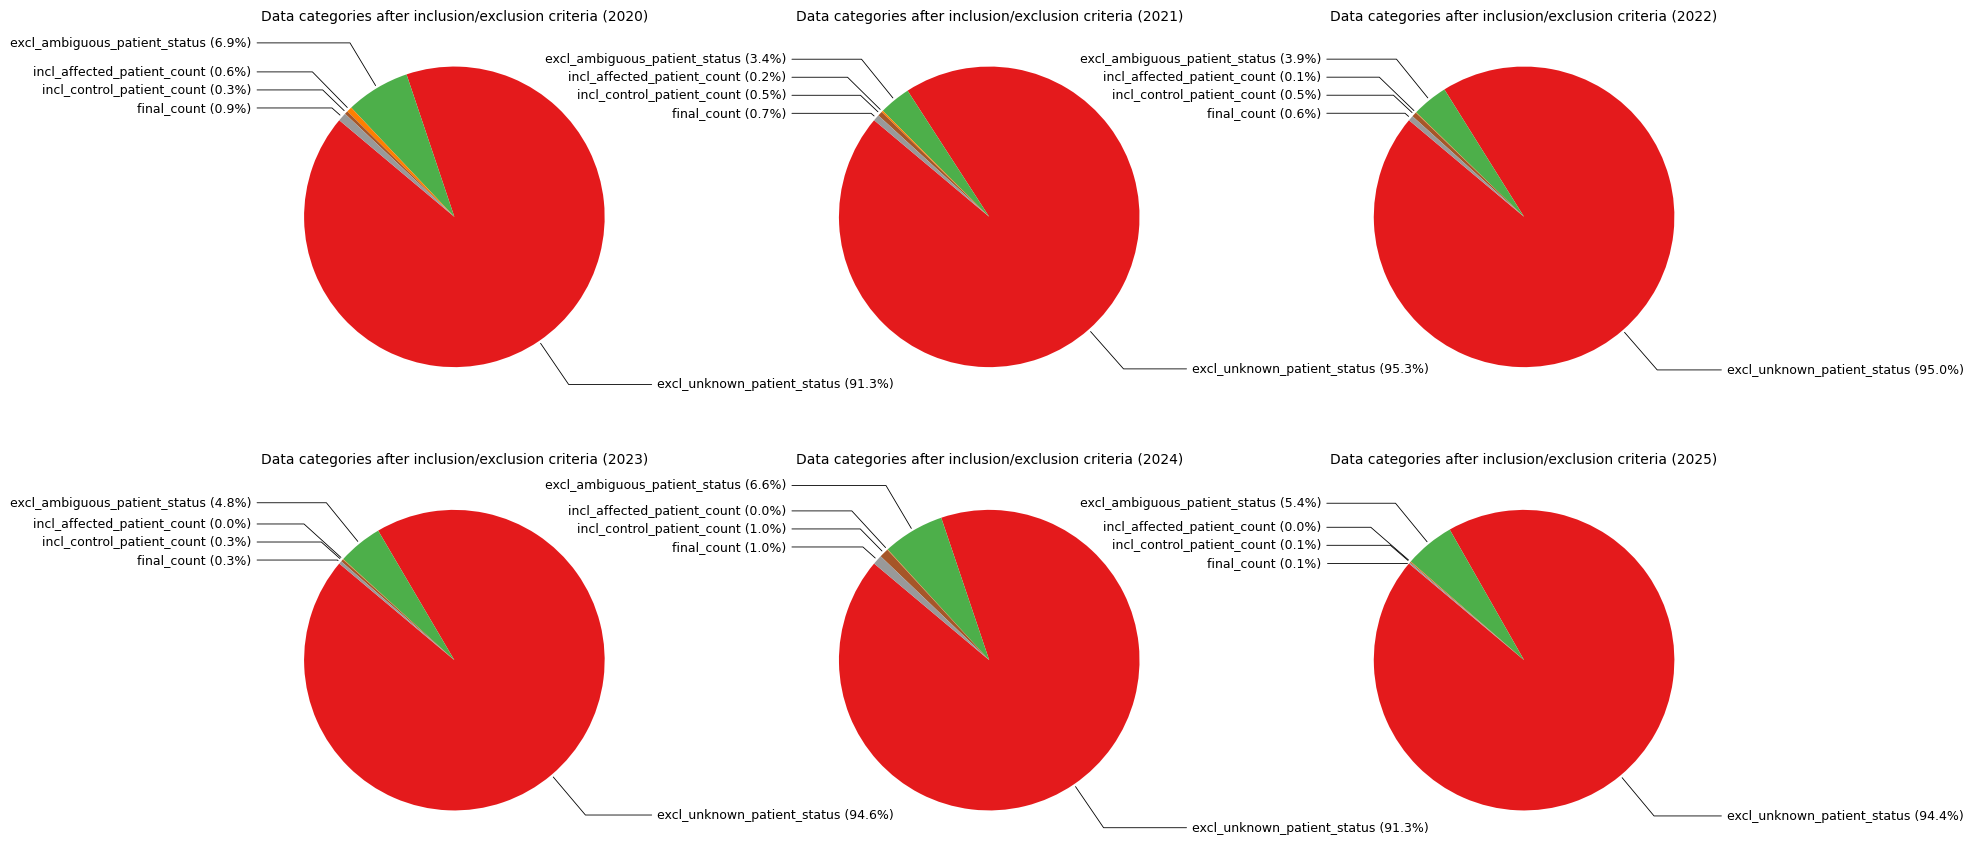

In [103]:
all_yrs = [split20, split21, split22, split23, split24, split25]
_ =plot_multiple_pies(all_yrs, n_cols=3, title_prefix="Data categories after inclusion/exclusion criteria")

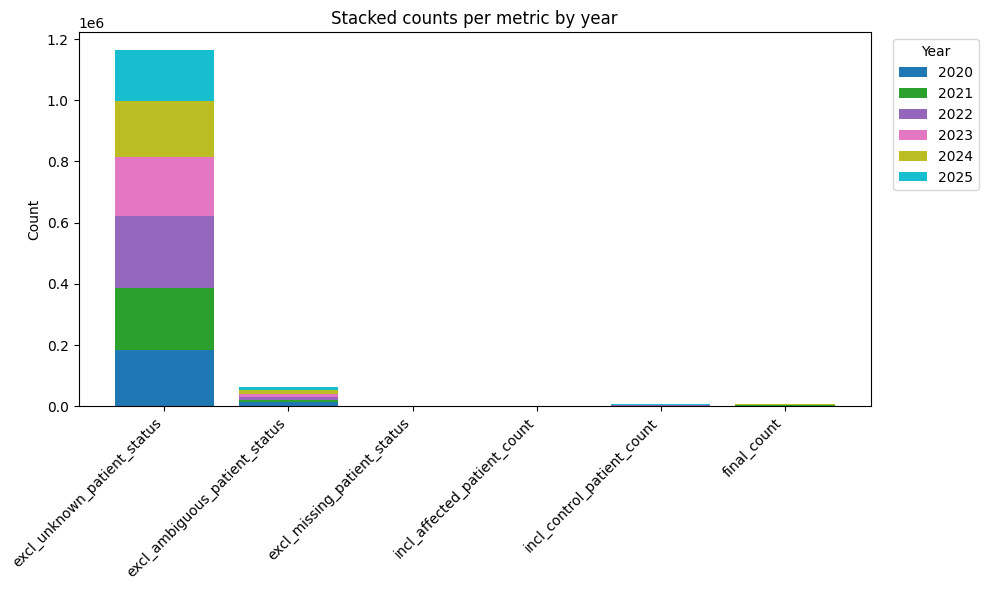

In [104]:
split_df = pd.DataFrame([eval(f"split{x}") for x in range(20, 26)])
metrics = [c for c in split_df.columns if c not in ["year", "total"]]
x = np.arange(len(metrics))
bottom = np.zeros(len(metrics), dtype=float)
colors = plt.cm.tab10(np.linspace(0, 1, len(split_df["year"].tolist())))

fig, ax = plt.subplots(figsize=(10, 6))
for i, yr_val in enumerate(split_df["year"].tolist()):
    vals = split_df.loc[i, metrics].astype(float).values
    ax.bar(x, vals, bottom=bottom, color=colors[i], label=str(yr_val))
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=45, ha="right")
ax.set_ylabel("Count")
ax.set_title("Stacked counts per metric by year")
ax.legend(title="Year", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

### Compare sequence collection/submission

In [105]:
for yr in range(2020, 2026):
    df = eval(f"df{str(yr)[-2:]}")
    print(f"*************************** Year: {yr} ***************************")
    inclusion_exclusion(df)

*************************** Year: 2020 ***************************
Exclusion 1: Removed 183410 samples with 'Unknown' patient status.
Exclusion 2: Removed 13844 samples with ambiguous patient status.
Exclusion 3: Removed 0 samples with missing patient status.
Inclusion 1: Included 1152 samples with severe patient status.
Inclusion 2: Included 699 samples with mild patient status.
Total samples after applying inclusion/exclusion criteria: 1851 (Removed 197254 samples out of 200524)
Percentage of meaningful samples: 0.92%
*************************** Year: 2021 ***************************
Exclusion 1: Removed 203850 samples with 'Unknown' patient status.
Exclusion 2: Removed 7252 samples with ambiguous patient status.
Exclusion 3: Removed 0 samples with missing patient status.
Inclusion 1: Included 371 samples with severe patient status.
Inclusion 2: Included 1082 samples with mild patient status.
Total samples after applying inclusion/exclusion criteria: 1453 (Removed 211102 samples out 

In [106]:
df_mas = pd.concat([df20, df21, df22, df23, df24, df25], ignore_index=True)
df_mas.shape

(1242390, 22)

In [107]:
inclusion_exclusion(df_mas)

Exclusion 1: Removed 1163715 samples with 'Unknown' patient status.
Exclusion 2: Removed 63193 samples with ambiguous patient status.
Exclusion 3: Removed 0 samples with missing patient status.
Inclusion 1: Included 1916 samples with severe patient status.
Inclusion 2: Included 5742 samples with mild patient status.
Total samples after applying inclusion/exclusion criteria: 7658 (Removed 1226908 samples out of 1242390)
Percentage of meaningful samples: 0.62%


(             accession_id submission_date  \
 0          EPI_ISL_491472      2020-07-17   
 1          EPI_ISL_677673      2020-12-05   
 2         EPI_ISL_1712659      2021-04-25   
 3          EPI_ISL_497972      2020-07-26   
 4          EPI_ISL_430272      2020-04-26   
 ...                   ...             ...   
 1242385  EPI_ISL_20252355      2025-11-19   
 1242386  EPI_ISL_20252474      2025-11-20   
 1242387  EPI_ISL_20252476      2025-11-20   
 1242388  EPI_ISL_20252478      2025-11-20   
 1242389  EPI_ISL_20252477      2025-11-20   
 
                                      Virus name collection_date  \
 0         hCoV-19/Philippines/PH-RITM-0017/2020      2020-03-04   
 1        hCoV-19/USA/NY-Wadsworth-10492-01/2020      2020-03-03   
 2                hCoV-19/Qatar/QA-QU_01-11/2020      2020-03-10   
 3             hCoV-19/South Korea/KCDC2071/2020      2020-02-20   
 4                      hCoV-19/USA/WA-S234/2020      2020-02-28   
 ...                                  

In [108]:
1 - (1164726/1242390)

0.06251177166590205

In [109]:
def get_abs_cumm_counts(df, date_col, year_col='collection_yr'):
    abs_counts = df.groupby(date_col).size().reset_index(name='abs_count')
    abs_counts['cumm_count'] = abs_counts['abs_count'].cumsum()
    abs_counts[year_col] = df[year_col].iloc[0]
    return abs_counts

In [110]:
# Collect number of sequences submitted each day
coll_20 = get_abs_cumm_counts(df20, 'collection_doy')
coll_21 = get_abs_cumm_counts(df21, 'collection_doy')
coll_22 = get_abs_cumm_counts(df22, 'collection_doy')
coll_23 = get_abs_cumm_counts(df23, 'collection_doy')
coll_24 = get_abs_cumm_counts(df24, 'collection_doy')
coll_25 = get_abs_cumm_counts(df25, 'collection_doy')
coll_20.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   collection_doy  186 non-null    int32
 1   abs_count       186 non-null    int64
 2   cumm_count      186 non-null    int64
 3   collection_yr   186 non-null    int32
dtypes: int32(2), int64(2)
memory usage: 4.5 KB


In [111]:
cols = ["accession_id", "collection_date", "submission_date", "collection_yr", "submission_yr", "collection_doy", "submission_doy", "location"]
df1 = pd.concat([df20[cols], df21[cols], df22[cols], df23[cols], df24[cols], df25[cols]], ignore_index=True)
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1242390 entries, 0 to 1242389
Data columns (total 8 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   accession_id     1242390 non-null  object        
 1   collection_date  1242390 non-null  datetime64[ns]
 2   submission_date  1242390 non-null  datetime64[ns]
 3   collection_yr    1242390 non-null  int32         
 4   submission_yr    1242390 non-null  int32         
 5   collection_doy   1242390 non-null  int32         
 6   submission_doy   1242390 non-null  int32         
 7   location         1242390 non-null  object        
dtypes: datetime64[ns](2), int32(4), object(2)
memory usage: 56.9+ MB


In [112]:
coll_df = pd.concat([coll_20, coll_21, coll_22, coll_23, coll_24, coll_25], axis=0)
coll_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 675 entries, 0 to 321
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   collection_doy  675 non-null    int32
 1   abs_count       675 non-null    int64
 2   cumm_count      675 non-null    int64
 3   collection_yr   675 non-null    int32
dtypes: int32(2), int64(2)
memory usage: 21.1 KB


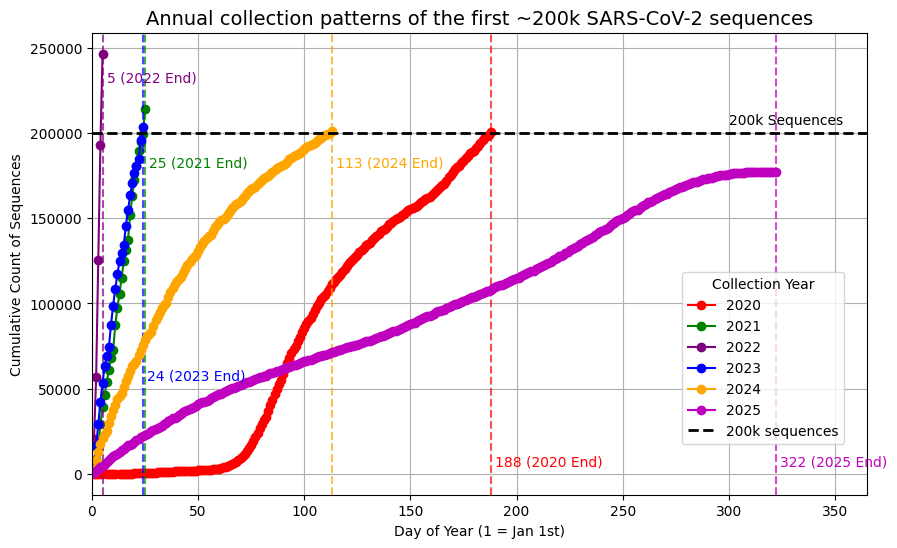

In [113]:
# 3. Plotting
plt.figure(figsize=(10, 6))

# Option A: Density Plot (The "Spike" vs "Hill")
# 'common_norm=False' allows each year to be normalized to its own volume, 
# showing the shape clearly regardless of total count differences.
# sns.catplot(data=coll_df, x='collection_doy', y='cumm_count', hue='collection_yr', palette='viridis', kind='bar', height=6, aspect=1.5)
plt.plot(coll_20['collection_doy'], coll_20['cumm_count'], color='r', marker='o', label='2020')
plt.axvline(coll_20['collection_doy'].max() , color='r', alpha=0.7, linewidth=1.5, linestyle='--')
plt.plot(coll_21['collection_doy'], coll_21['cumm_count'], color='g', marker='o', label='2021')
plt.axvline(coll_21['collection_doy'].max() , color='g', alpha=0.7, linewidth=1.5, linestyle='--')
plt.plot(coll_22['collection_doy'], coll_22['cumm_count'], color='purple', marker='o', label='2022')
plt.axvline(coll_22['collection_doy'].max() , color='purple', alpha=0.7, linewidth=1.5, linestyle='--')
plt.plot(coll_23['collection_doy'], coll_23['cumm_count'], color='b', marker='o', label='2023')
plt.axvline(coll_23['collection_doy'].max() , color='b', alpha=0.7, linewidth=1.5, linestyle='--')
plt.plot(coll_24['collection_doy'], coll_24['cumm_count'], color='orange', marker='o', label='2024')
plt.axvline(coll_24['collection_doy'].max() , color='orange', alpha=0.7, linewidth=1.5, linestyle='--')
plt.plot(coll_25['collection_doy'], coll_25['cumm_count'], color='m', marker='o', label='2025')
plt.axvline(coll_25['collection_doy'].max() , color='m', alpha=0.7, linewidth=1.5, linestyle='--')
plt.axhline(2e5 , color='black', linewidth=2, linestyle='--', label='200k sequences')
plt.legend(title='Collection Year', loc='lower right', bbox_to_anchor=(0.98, 0.095))

# Annotate vlines and hline
plt.text(coll_20['collection_doy'].max()+2, 5000, f'{coll_20["collection_doy"].max()} (2020 End)', color='r')
plt.text(coll_21['collection_doy'].max()+2, 180000, f'{coll_21["collection_doy"].max()} (2021 End)', color='g')
plt.text(coll_22['collection_doy'].max()+2, 230000, f'{coll_22["collection_doy"].max()} (2022 End)', color='purple')
plt.text(coll_23['collection_doy'].max()+2, 55000, f'{coll_23["collection_doy"].max()} (2023 End)', color='b')
plt.text(coll_24['collection_doy'].max()+2, 180000, f'{coll_24["collection_doy"].max()} (2024 End)', color='orange')
plt.text(coll_25['collection_doy'].max()+2, 5000, f'{coll_25["collection_doy"].max()} (2025 End)', color='m')
plt.text(300, 2e5 + 5000, '200k Sequences', color='black')

plt.title("Annual collection patterns of the first ~200k SARS-CoV-2 sequences", fontsize=14)
plt.xlabel("Day of Year (1 = Jan 1st)")
plt.ylabel("Cumulative Count of Sequences")
plt.xlim(0, 365) # Lock to a full year view
plt.grid(True)
plt.show()

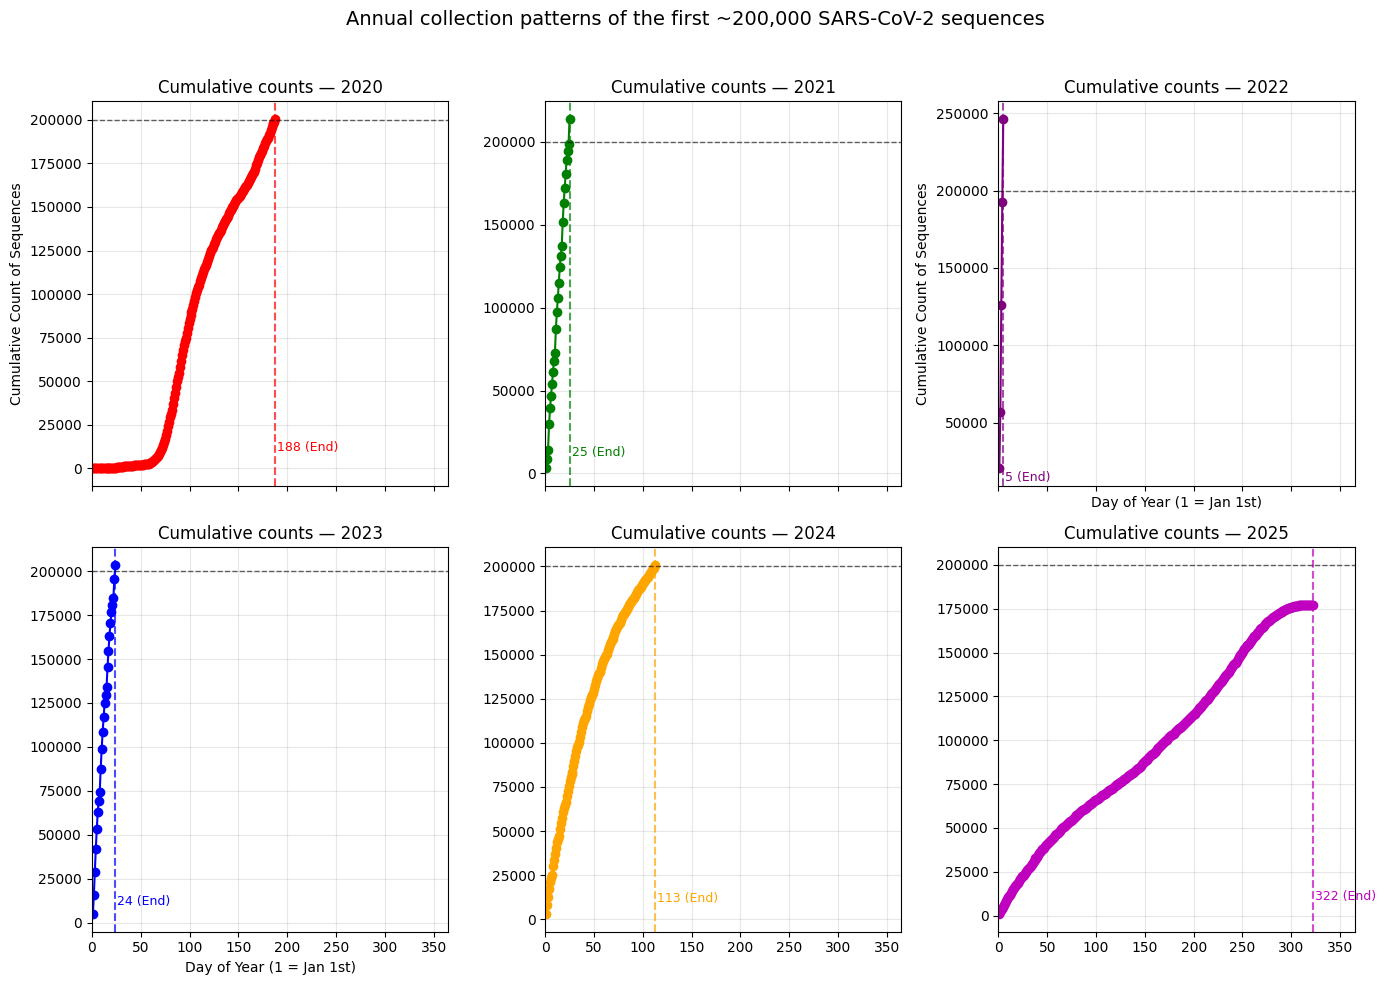

In [114]:
# 3. Plotting — one subplot per year
fig, axes = plt.subplots(2, 3, figsize=(14, 10), sharex=True)
axes = axes.ravel()

datasets = [
    (coll_20, "2020", "r"),
    (coll_21, "2021", "g"),
    (coll_22, "2022", "purple"),
    (coll_23, "2023", "b"),
    (coll_24, "2024", "orange"),
    (coll_25, "2025", "m"),
]

for ax, (df, year, color) in zip(axes, datasets):
    ax.plot(df["collection_doy"], df["cumm_count"], color=color, marker="o", label=year)
    ax.axvline(df["collection_doy"].max(), color=color, alpha=0.7, linewidth=1.5, linestyle="--")
    ax.axhline(2e5, color="black", linewidth=1, linestyle="--", alpha=0.6)
    ax.set_title(f"Cumulative counts — {year}")
    ax.set_xlim(0, 365)
    ax.grid(True, alpha=0.3)
    xpos = df["collection_doy"].max() + 2
    ypos = max(df["cumm_count"].max() * 0.05, 1)
    ax.text(xpos, ypos, f"{df['collection_doy'].max()} (End)", color=color, fontsize=9)

# Axis labels
for a in axes[[2, 3]]:
    a.set_xlabel("Day of Year (1 = Jan 1st)")
for a in axes[[0, 2]]:
    a.set_ylabel("Cumulative Count of Sequences")

fig.suptitle("Annual collection patterns of the first ~200,000 SARS-CoV-2 sequences", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

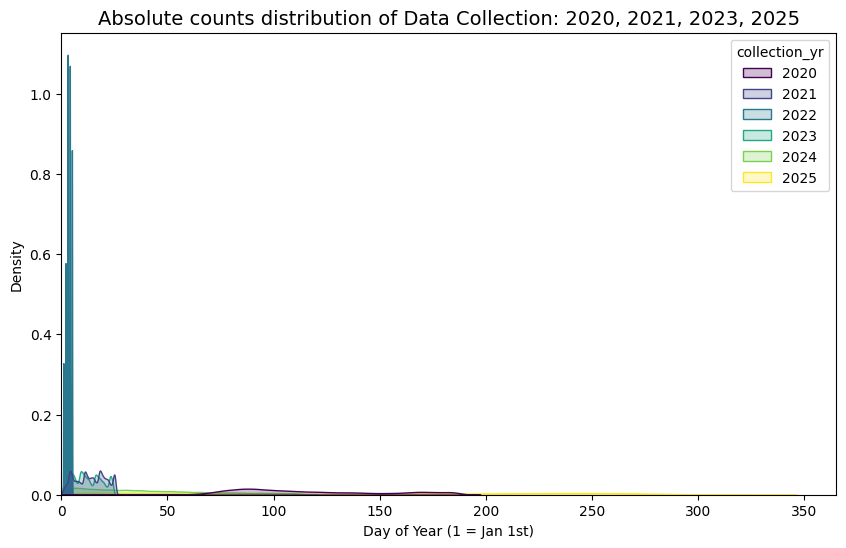

In [115]:
# 3. Plotting
plt.figure(figsize=(10, 6))

# Option A: Density Plot (The "Spike" vs "Hill")
# 'common_norm=False' allows each year to be normalized to its own volume, 
# showing the shape clearly regardless of total count differences.
sns.kdeplot(data=df1, x='collection_doy', hue='collection_yr', fill=True, common_norm=False, palette='viridis')

plt.title("Absolute counts distribution of Data Collection: 2020, 2021, 2023, 2025", fontsize=14)
plt.xlabel("Day of Year (1 = Jan 1st)")
plt.xlim(0, 365) # Lock to a full year view
plt.show()

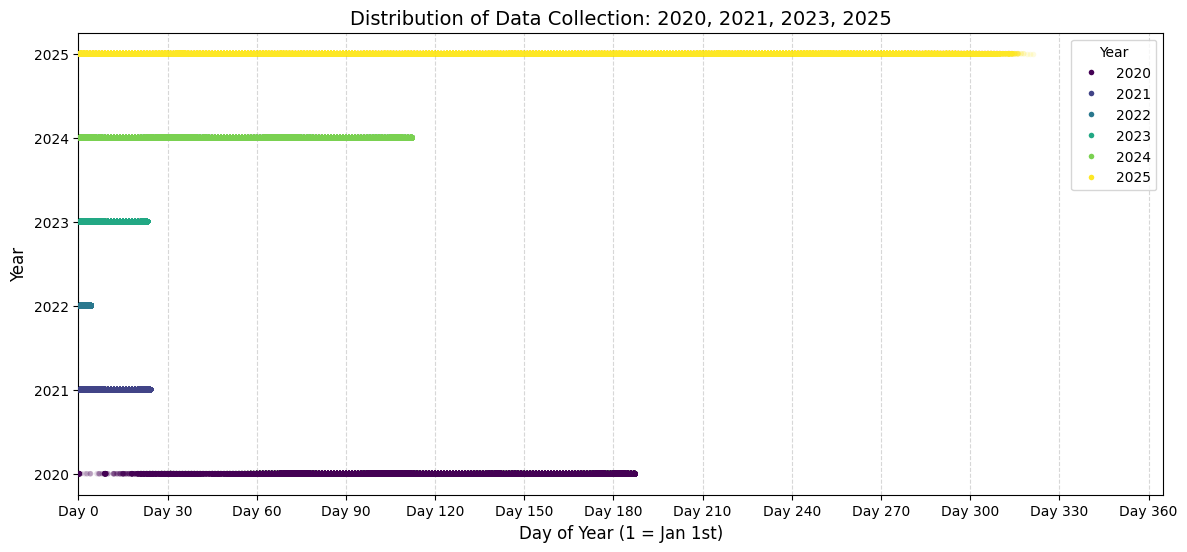

In [116]:
plt.figure(figsize=(14, 6))

# 3. Create Strip Plot
    # TIP: We use .sample(frac=0.1) to plot only 10% of data for speed/clarity. 
    # If you want all data, remove .sample() but lower 'alpha' and 'size'.
ax = sns.stripplot(
    # data=df.sample(frac=0.1, random_state=42),
    data=df1,  
    x='collection_doy', 
    y='collection_yr',           # Categorical Y-axis separates the years
    hue='collection_yr',         # Colors them differently
    jitter=0.25,        # Adds random vertical noise so dots don't overlap perfectly
    size=4,             # Keep dots small
    alpha=0.15,          # High transparency to show density (darker = more data)
    palette='viridis'
)

# plt.title("Timeline of Data Collection by Year (Strip Plot)", fontsize=14)
plt.title("Distribution of Data Collection: 2020, 2021, 2023, 2025", fontsize=14)
plt.xlabel("Day of Year (1 = Jan 1st)", fontsize=12)
plt.ylabel("Year", fontsize=12)
plt.xlim(0, 365)  # Lock axis to full year
plt.grid(True, axis='x', linestyle='--', alpha=0.5)

plt.xticks(ticks=np.arange(0, 366, 30), labels=[f"Day {i}" for i in np.arange(0, 366, 30)])
plt.legend(title='Year', loc='upper right')

legend = ax.get_legend()

# Loop through the legend handles (markers) and make them opaque
if legend:
    for handle in legend.legend_handles:
        handle.set_alpha(1.0)  # 1.0 = Fully Opaque

plt.show()

In [117]:
def get_submission_yr(df, year=2020):
    df_sub = df[df['submission_yr'] == year]
    return get_abs_cumm_counts(df_sub, 'submission_doy', 'submission_yr')

In [118]:
sub_20 = get_submission_yr(df1, 2020)
sub_21 = get_submission_yr(df1, 2021)
sub_22 = get_submission_yr(df1, 2022)
sub_23 = get_submission_yr(df1, 2023)
sub_24 = get_submission_yr(df1, 2024)
sub_25 = get_submission_yr(df1, 2025)

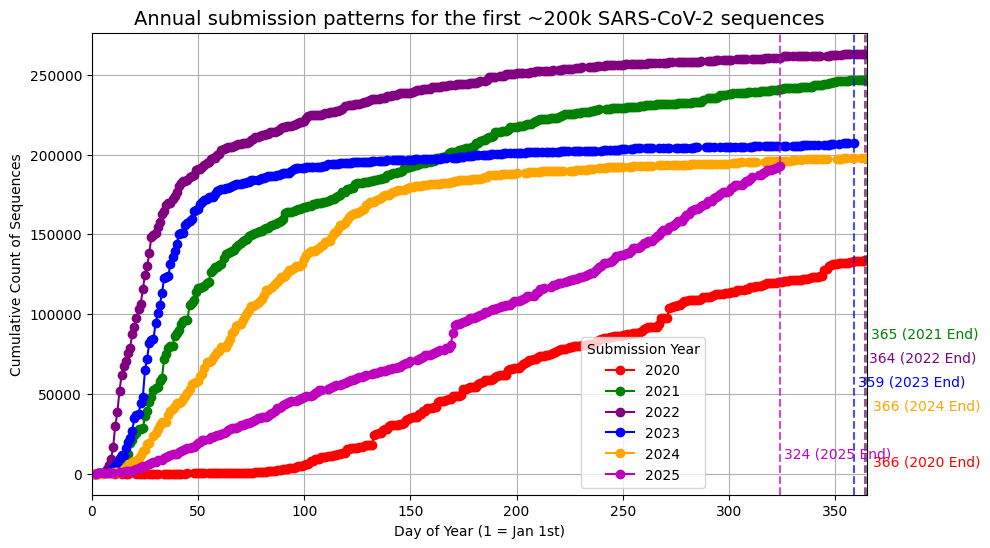

In [119]:
# 3. Plotting
plt.figure(figsize=(10, 6))

# Option A: Density Plot (The "Spike" vs "Hill")
# 'common_norm=False' allows each year to be normalized to its own volume, 
# showing the shape clearly regardless of total count differences.
# sns.catplot(data=coll_df, x='collection_doy', y='cumm_count', hue='collection_yr', palette='viridis', kind='bar', height=6, aspect=1.5)
plt.plot(sub_20['submission_doy'], sub_20['cumm_count'], color='r', marker='o', label='2020')
plt.axvline(sub_20['submission_doy'].max() , color='r', alpha=0.7, linewidth=1.5, linestyle='--')
plt.plot(sub_21['submission_doy'], sub_21['cumm_count'], color='g', marker='o', label='2021')
plt.axvline(sub_21['submission_doy'].max() , color='g', alpha=0.7, linewidth=1.5, linestyle='--')
plt.plot(sub_22['submission_doy'], sub_22['cumm_count'], color='purple', marker='o', label='2022')
plt.axvline(sub_22['submission_doy'].max() , color='purple', alpha=0.7, linewidth=1.5, linestyle='--')
plt.plot(sub_23['submission_doy'], sub_23['cumm_count'], color='b', marker='o', label='2023')
plt.axvline(sub_23['submission_doy'].max() , color='b', alpha=0.7, linewidth=1.5, linestyle='--')
plt.plot(sub_24['submission_doy'], sub_24['cumm_count'], color='orange', marker='o', label='2024')
plt.axvline(sub_24['submission_doy'].max() , color='orange', alpha=0.7, linewidth=1.5, linestyle='--')
plt.plot(sub_25['submission_doy'], sub_25['cumm_count'], color='m', marker='o', label='2025')
plt.axvline(sub_25['submission_doy'].max() , color='m', alpha=0.7, linewidth=1.5, linestyle='--')
plt.legend(title='Submission Year', loc='lower right', bbox_to_anchor=(0.8, 0.0))

# Annotate vlines and hline
plt.text(sub_20['submission_doy'].max()+2, 5000, f'{sub_20["submission_doy"].max()} (2020 End)', color='r')
plt.text(sub_21['submission_doy'].max()+2, 85000, f'{sub_21["submission_doy"].max()} (2021 End)', color='g')
plt.text(sub_22['submission_doy'].max()+2, 70000, f'{sub_22["submission_doy"].max()} (2022 End)', color='purple')
plt.text(sub_23['submission_doy'].max()+2, 55000, f'{sub_23["submission_doy"].max()} (2023 End)', color='b')
plt.text(sub_24['submission_doy'].max()+2, 40000, f'{sub_24["submission_doy"].max()} (2024 End)', color='orange')
plt.text(sub_25['submission_doy'].max()+2, 10000, f'{sub_25["submission_doy"].max()} (2025 End)', color='m')

plt.title("Annual submission patterns for the first ~200k SARS-CoV-2 sequences", fontsize=14)
plt.xlabel("Day of Year (1 = Jan 1st)")
plt.ylabel("Cumulative Count of Sequences")
plt.xlim(0, 365) # Lock to a full year view
plt.grid(True)
plt.show()

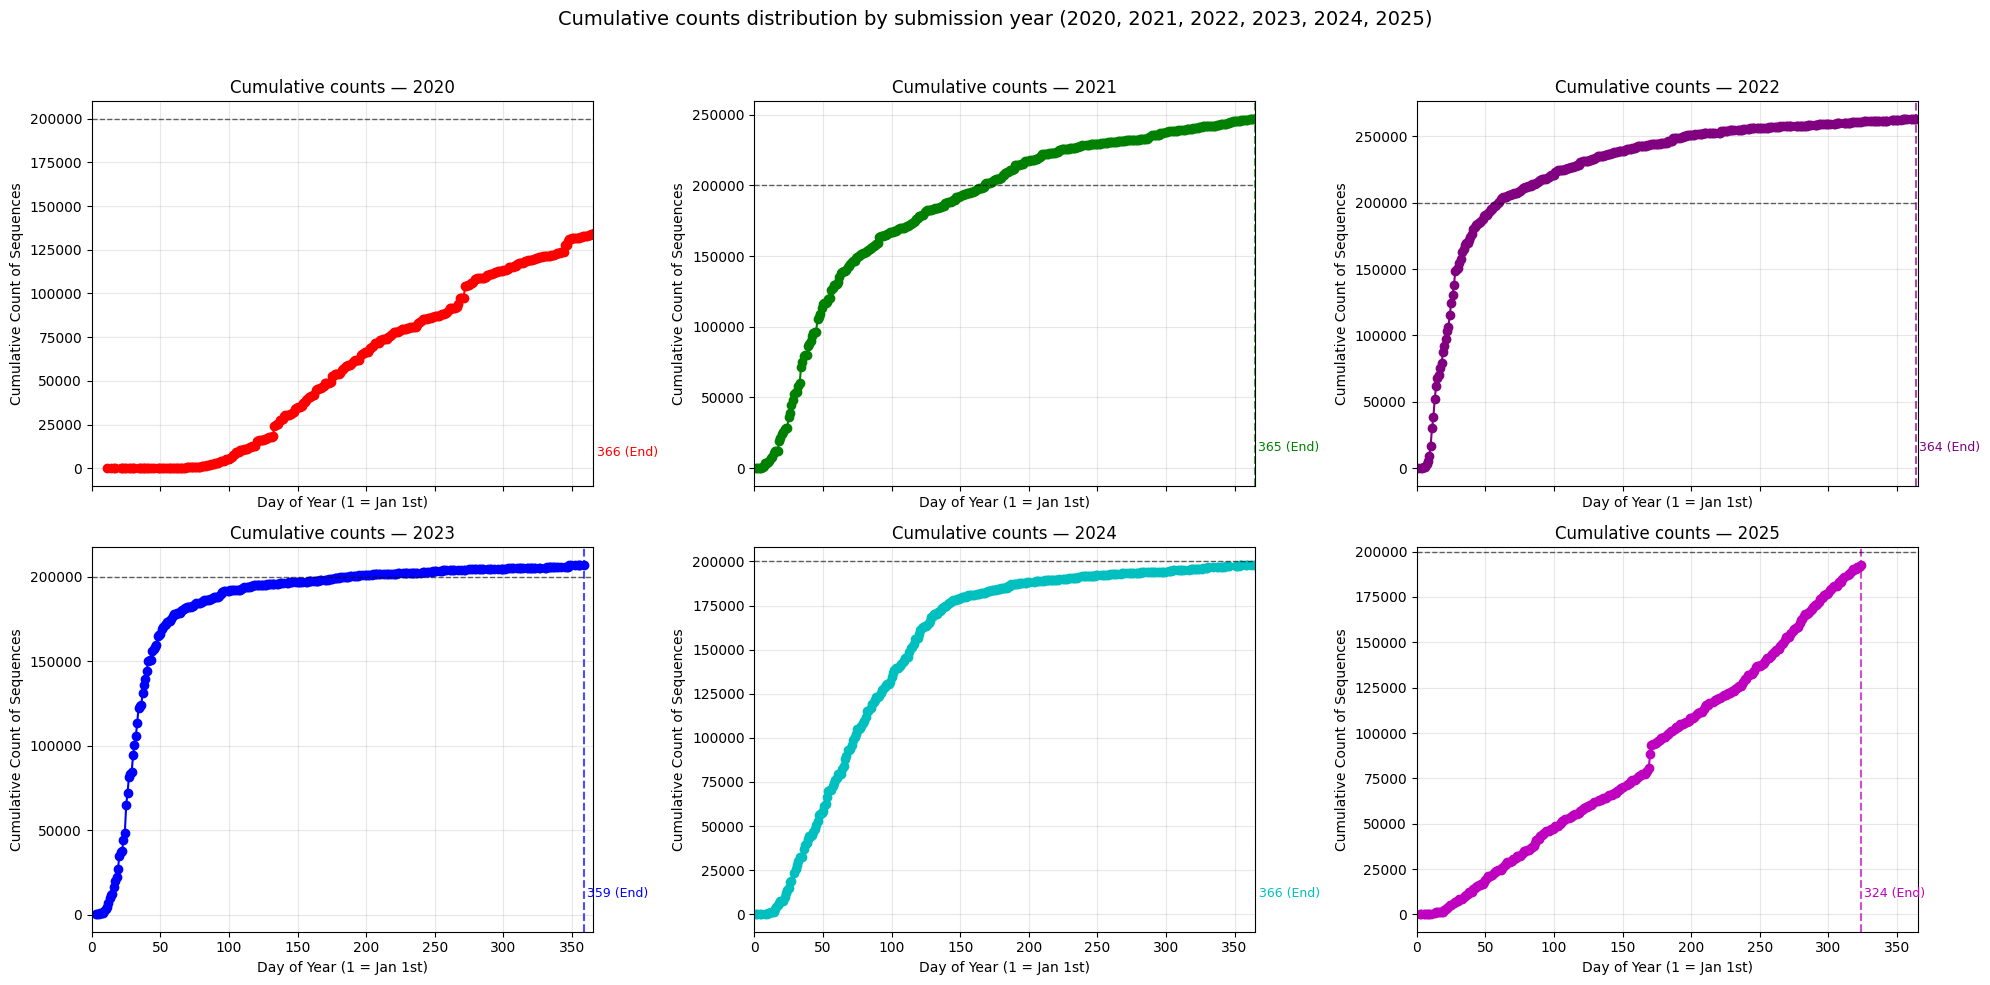

In [120]:
# 3. Plotting — one subplot per year
fig, axes = plt.subplots(2, 3, figsize=(20, 10), sharex=True)
axes = axes.ravel()

datasets = [
    (sub_20, "2020", "r"),
    (sub_21, "2021", "g"),
    (sub_22, "2022", "purple"),
    (sub_23, "2023", "b"),
    (sub_24, "2024", "c"),
    (sub_25, "2025", "m"),
]

for ax, (df, year, color) in zip(axes, datasets):
    ax.plot(df["submission_doy"], df["cumm_count"], color=color, marker="o", label=year)
    ax.axvline(df["submission_doy"].max(), color=color, alpha=0.7, linewidth=1.5, linestyle="--")
    ax.axhline(2e5, color="black", linewidth=1, linestyle="--", alpha=0.6)
    ax.set_title(f"Cumulative counts — {year}")
    ax.set_xlim(0, 365)
    ax.grid(True, alpha=0.3)
    xpos = df["submission_doy"].max() + 2
    ypos = max(df["cumm_count"].max() * 0.05, 1)
    ax.text(xpos, ypos, f"{df['submission_doy'].max()} (End)", color=color, fontsize=9)

# Axis labels
for a in axes:
    a.set_xlabel("Day of Year (1 = Jan 1st)")
for a in axes:
    a.set_ylabel("Cumulative Count of Sequences")

fig.suptitle("Cumulative counts distribution by submission year (2020, 2021, 2022, 2023, 2024, 2025)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

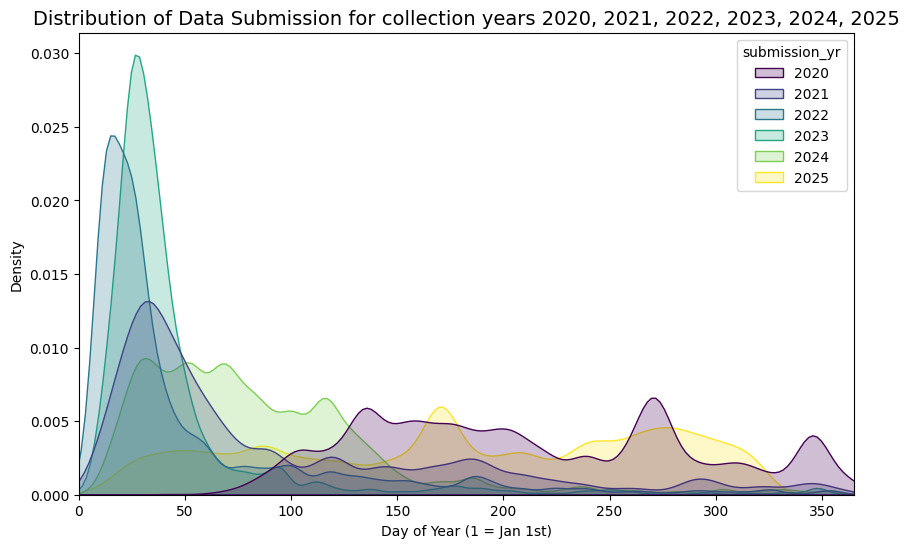

In [121]:
# 3. Plotting
plt.figure(figsize=(10, 6))

# Option A: Density Plot (The "Spike" vs "Hill")
# 'common_norm=False' allows each year to be normalized to its own volume, 
# showing the shape clearly regardless of total count differences.
sns.kdeplot(data=df1, x='submission_doy', hue='submission_yr', fill=True, common_norm=False, palette='viridis')

plt.title("Distribution of Data Submission for collection years 2020, 2021, 2022, 2023, 2024, 2025", fontsize=14)
plt.xlabel("Day of Year (1 = Jan 1st)")
plt.xlim(0, 365) # Lock to a full year view
plt.show()

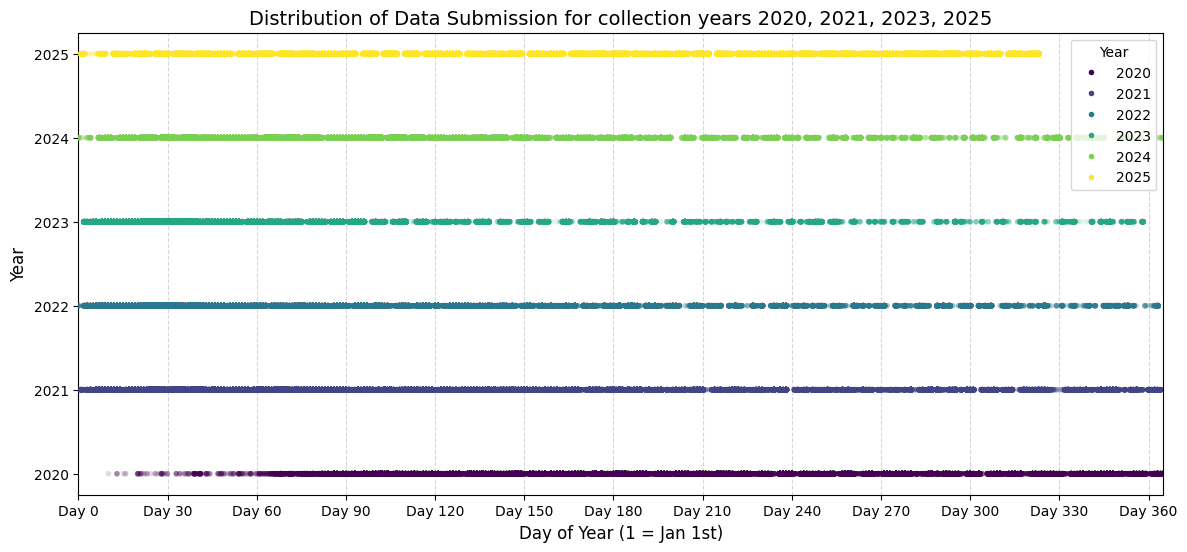

In [122]:
plt.figure(figsize=(14, 6))

# 3. Create Strip Plot
    # TIP: We use .sample(frac=0.1) to plot only 10% of data for speed/clarity. 
    # If you want all data, remove .sample() but lower 'alpha' and 'size'.
ax = sns.stripplot(
    # data=df.sample(frac=0.1, random_state=42),
    data=df1,  
    x='submission_doy', 
    y='submission_yr',           # Categorical Y-axis separates the years
    hue='submission_yr',         # Colors them differently
    jitter=0.25,        # Adds random vertical noise so dots don't overlap perfectly
    size=4,             # Keep dots small
    alpha=0.15,          # High transparency to show density (darker = more data)
    palette='viridis'
)

# plt.title("Timeline of Data Collection by Year (Strip Plot)", fontsize=14)
plt.title("Distribution of Data Submission for collection years 2020, 2021, 2023, 2025", fontsize=14)
plt.xlabel("Day of Year (1 = Jan 1st)", fontsize=12)
plt.ylabel("Year", fontsize=12)
plt.xlim(0, 365)  # Lock axis to full year
plt.grid(True, axis='x', linestyle='--', alpha=0.5)

plt.xticks(ticks=np.arange(0, 366, 30), labels=[f"Day {i}" for i in np.arange(0, 366, 30)])
plt.legend(title='Year', loc='upper right')

legend = ax.get_legend()

# Loop through the legend handles (markers) and make them opaque
if legend:
    for handle in legend.legend_handles:
        handle.set_alpha(1.0)  # 1.0 = Fully Opaque

plt.show()

## Compare cleaned data

As seen in previous section, the ~200k sequences are collected in different time spans across years. So, to truly compare the fraction of meaningful data etc, we need to compare the densities for each year. Here, we just define density as number of sequences collected per day.

In [123]:
split_df

,year,total,excl_unknown_patient_status,excl_ambiguous_patient_status,excl_missing_patient_status,incl_affected_patient_count,incl_control_patient_count,final_count
0,2020,200524,183410,13844,0,1152,699,1851
1,2021,213997,203850,7252,0,371,1082,1453
2,2022,246359,234849,9553,0,124,1270,1394
3,2023,203488,192413,9761,0,93,542,635
4,2024,200906,183462,13355,0,92,1987,2079
5,2025,177116,165731,9428,0,84,162,246


In [124]:
split_df["collection_density"] = 0.0
split_df["unknown_pat_stat_density"] = 0.0
# Calculate collection density per year
for i,row in split_df.iterrows():
    yr = int(row['year'])
    df_string = str(yr)[-2:]
    df = eval(f"df{df_string}")
    num_days = df['collection_date'].nunique()

    # Get density values
    density = row["total"] / num_days if num_days > 0 else 0
    split_df.at[i, 'collection_density'] = density
    split_df.at[i, "unknown_pat_stat_density"] = row['excl_unknown_patient_status']/num_days if num_days > 0 else 0

for i,row in split_df.iterrows():
    yr = int(row['year'])
    df_string = str(yr)[-2:]
    df = eval(f"df{df_string}")
    num_days = df['collection_date'].nunique()
    # Display results
    print(f"**************************** Year: {yr} ***************************")
    print(f"Total sequences: {row['total']}")
    print(f"Unique collection days: {num_days}")
    print(f"Collection density: {row['collection_density']:.2f} sequences/day")
    print(f"Unknown patient status density: {row['unknown_pat_stat_density']:.2f} sequences/day")
    print(f"Percentage of non-unknown patient status: {100 * (1 - (row['unknown_pat_stat_density'] / row['collection_density'])):.2f}%")

    # Inclusion/exclusion summary
    print("Inclusion/Exclusion Summary:")
    filtered = row["collection_density"]
    for metric in [c for c in split_df.columns if c not in ["year", "total", "collection_density", "unknown_pat_stat_density"]]:
        count = row[metric]
        if metric.startswith("excl_"):
            filtered -= count / num_days if num_days > 0 else 0
        elif metric.startswith("incl_"):
            filtered += count / num_days if num_days > 0 else 0
    print(f"Final filtered collection density: {filtered:.2f} sequences/day and percentage: {100 * (filtered / row['collection_density']):.2f}%")
    print("\n")

**************************** Year: 2020 ***************************
Total sequences: 200524.0
Unique collection days: 186
Collection density: 1078.09 sequences/day
Unknown patient status density: 986.08 sequences/day
Percentage of non-unknown patient status: 8.53%
Inclusion/Exclusion Summary:
Final filtered collection density: 27.53 sequences/day and percentage: 2.55%


**************************** Year: 2021 ***************************
Total sequences: 213997.0
Unique collection days: 25
Collection density: 8559.88 sequences/day
Unknown patient status density: 8154.00 sequences/day
Percentage of non-unknown patient status: 4.74%
Inclusion/Exclusion Summary:
Final filtered collection density: 173.92 sequences/day and percentage: 2.03%


**************************** Year: 2022 ***************************
Total sequences: 246359.0
Unique collection days: 5
Collection density: 49271.80 sequences/day
Unknown patient status density: 46969.80 sequences/day
Percentage of non-unknown patient s

In [125]:
df_mas.shape[0]/df_mas['collection_date'].nunique(), df_mas['collection_date'].nunique()

(1840.5777777777778, 675)

In [126]:
df_mas[df_mas["Patient status"].astype(str).str.lower().isin(["unknown"])].shape[0]/df_mas["collection_date"].nunique()

1724.0222222222221

In [127]:
for yr in df_mas["collection_yr"].unique().tolist():
    df = df_mas[df_mas["collection_yr"]==yr]
    m_data = 0
    final_meaningful = 0
    for d in df["collection_date"].unique().tolist():
        day_df = df[df["collection_date"]==d]
        _, day_counts = inclusion_exclusion(day_df, yr, verbose=False)
        m_data += day_counts['final_count']/day_counts['total']
        final_meaningful += day_counts['final_count']
    print(f"{yr}: {m_data/df["collection_date"].nunique()} vs {final_meaningful/df.shape[0]}")

2020: 0.016666940973626795 vs 0.009230815264008298
2021: 0.007095698718400747 vs 0.006789814810487998
2022: 0.005508627952501217 vs 0.005658409069690979
2023: 0.003196530875162612 vs 0.003120577134769618
2024: 0.010116600215462323 vs 0.010348123002797327
2025: 0.0015160744188750395 vs 0.0013889202556516633


In [128]:
x, y = 0, 0
for d in df_mas["collection_date"].unique().tolist():
    day_df = df_mas[df_mas["collection_date"]==d]
    _, day_counts = inclusion_exclusion(day_df, yr, verbose=False)
    x += day_counts['final_count']/day_counts['total']
    y += day_counts['final_count']
print(f"{yr}: {x/df_mas["collection_date"].nunique()} vs {y/df_mas.shape[0]}")

2025: 0.007426748380808908 vs 0.006163925981374609


## AI annotated patient status

In [129]:
DATA_DIR

'/home/asudarshan14/gcs-data/Full_data'

In [130]:
os.listdir(os.path.join(DATA_DIR, "models"))

['bi_gru_multitask_unweighted_model_20Dec25.pth',
 'bi_gru_multitask_weighted_model_20Dec25.pth',
 'patient_status_mapped_AI_20Dec25.csv',
 'patient_status_mapped_AI_20Dec25_all_en_train_20Jan2026.csv',
 'patient_status_mapped_AI_20Dec25_all_en_train_Jan2026.csv',
 'patient_status_mapped_AI_20Dec25_v2.csv']

In [131]:
df_pat = pd.read_csv(os.path.join(DATA_DIR, "models/patient_status_mapped_AI_20Dec25_all_en_train_20Jan2026.csv"))
df_pat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194 entries, 0 to 193
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   patient_status     194 non-null    object
 1   clinical_status    194 non-null    object
 2   hospital_status    194 non-null    object
 3   severity           194 non-null    object
 4   who_category       194 non-null    object
 5   source_lang        194 non-null    object
 6   patient_status_en  194 non-null    object
 7   pat_stat_lower     194 non-null    object
 8   word_count         194 non-null    int64 
 9   bi_gru_status      194 non-null    object
 10  bi_gru_hosp        194 non-null    object
 11  bi_gru_severity    194 non-null    object
 12  bi_gru_category    194 non-null    object
dtypes: int64(1), object(12)
memory usage: 19.8+ KB


In [132]:
df_pat[df_pat["patient_status"].isna()]

,patient_status,clinical_status,hospital_status,severity,who_category,source_lang,patient_status_en,pat_stat_lower,word_count,bi_gru_status,bi_gru_hosp,bi_gru_severity,bi_gru_category


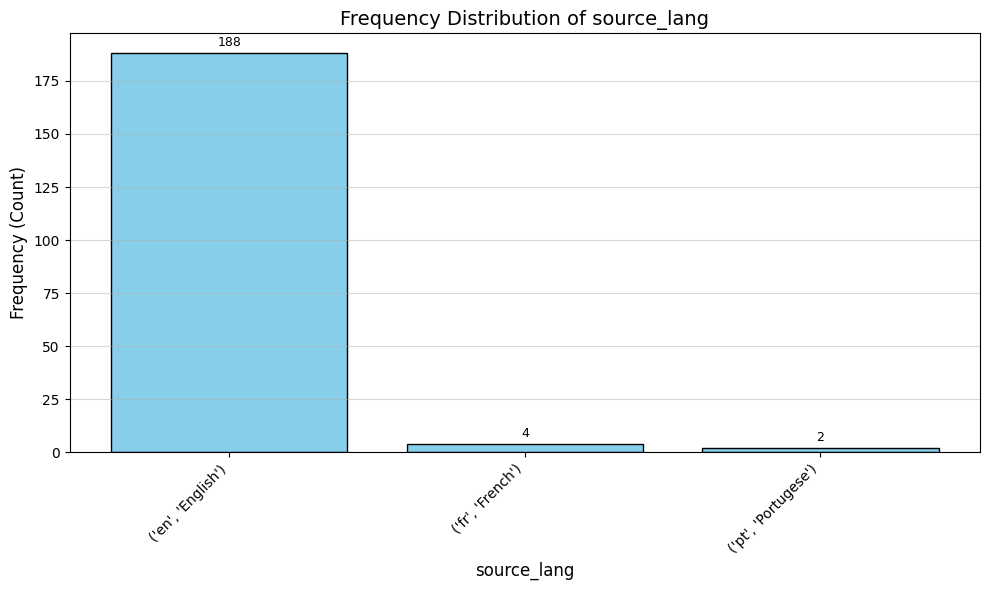

In [133]:
plot_hist(df_pat, "source_lang")

In [134]:
df_pat["severity"].value_counts()

severity
mild          90
unknown       34
severe        25
moderate      24
uninfected    15
dead           6
Name: count, dtype: int64

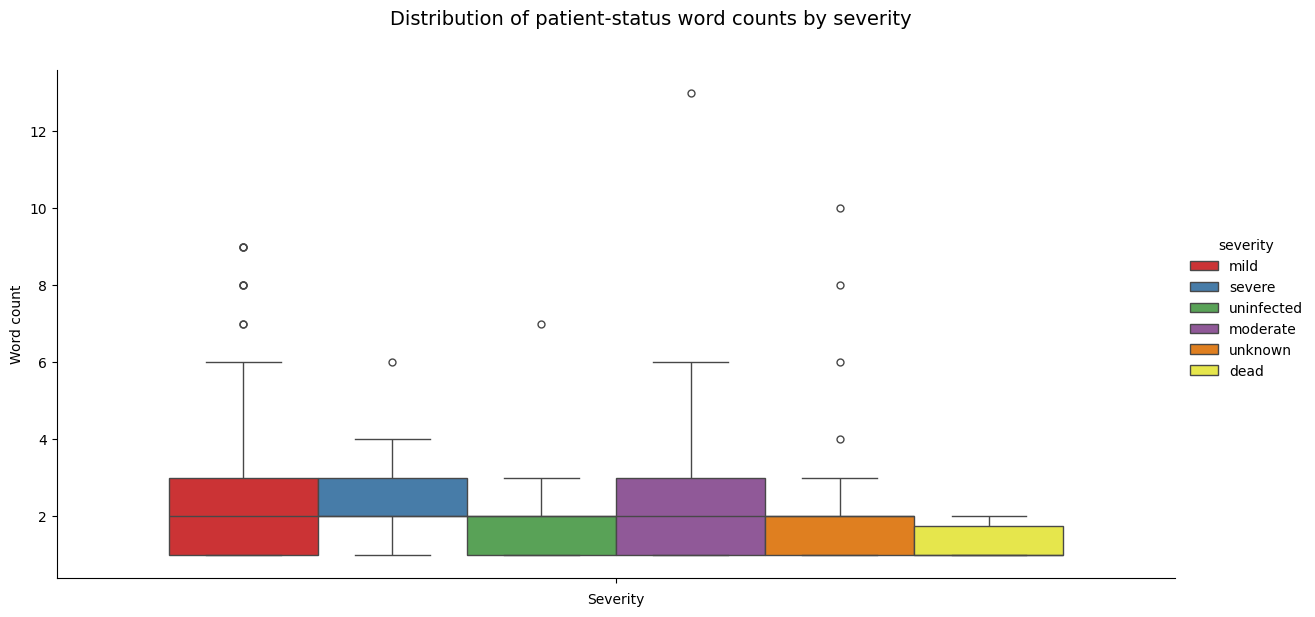

In [135]:
import seaborn as sns

g = sns.catplot(data=df_pat, y="word_count", hue="severity", kind="box", height=6, aspect=2, palette="Set1")
ax = g.ax

# Title and axis labels
g.set_axis_labels("Severity", "Word count")
g.fig.suptitle("Distribution of patient-status word counts by severity", fontsize=14)
g.fig.subplots_adjust(top=0.88)

# Annotations: show count and median per severity
medians = df_pat.groupby("severity")["word_count"].median().to_dict()
counts = df_pat["severity"].value_counts().to_dict()
for i, tick in enumerate(ax.get_xticklabels()):
    label = tick.get_text()
    med = medians.get(label, 0)
    cnt = counts.get(label, 0)
    y = med + max(1.0, med * 0.05)
    # ax.text(i, y, f"n={cnt}\nmed={med:.1f}", ha="center", va="bottom", fontsize=9, color="black")

In [136]:
data = []
for s in df_pat["severity"].unique().tolist():
    print(s)
    sub_df = df_pat[df_pat["severity"]==s]
    data.append(sub_df["word_count"].describe().to_dict())
pd.DataFrame(data, index=df_pat["severity"].unique().tolist())

mild
severe
uninfected
moderate
unknown
dead


,count,mean,std,min,25%,50%,75%,max
mild,90.0,2.455556,2.136684,1.0,1.0,2.0,3.00,9.0
severe,25.0,2.360000,1.113553,1.0,2.0,2.0,3.00,6.0
uninfected,15.0,1.933333,1.533747,1.0,1.0,2.0,2.00,7.0
moderate,24.0,2.666667,2.581989,1.0,1.0,2.0,3.00,13.0
unknown,34.0,2.294118,2.008005,1.0,1.0,2.0,2.00,10.0
dead,6.0,1.333333,0.516398,1.0,1.0,1.0,1.75,2.0


In [137]:
a = set(df_mas["Patient status"].astype(str).str.lower().unique().tolist()) 
b = set(df_pat["patient_status"].astype(str).str.lower().unique().tolist())
len(a - b), len(b - a), len((a-b).union(b - a))

(29, 0, 29)

In [138]:
a-b

{'admitted for two days with covid pneumonia',
 'aspirado',
 'assymptomatic',
 'asymptomatic - ambulatory',
 'deceased (bid)',
 'deceased (brought in dead)',
 'die',
 'female',
 'healthcare worker',
 'hisopado',
 'home isolated',
 'home isolation',
 'hospital cases',
 'hospitalizado',
 'hospitalization',
 'hospitalized, live',
 'hospitalized, severe',
 'hotel isolation',
 'intensive care',
 'live - intensive care unit',
 'mild disease',
 'mild; lost at follow-up',
 'mild; recovered',
 'missing',
 'nurse-house',
 'realesed, live',
 'recovered (no symptoms)',
 'senitel',
 'symptomatic - ambulatory'}

In [139]:
dfs = []
for yr in range(2020, 2026):
    df = eval(f"df{str(yr)[-2:]}")
    print(f"*************************** Year: {yr} ***************************")
    df, split = inclusion_exclusion(df, yr)
    dfs.append((df, split))

*************************** Year: 2020 ***************************
Exclusion 1: Removed 183410 samples with 'Unknown' patient status.
Exclusion 2: Removed 13844 samples with ambiguous patient status.
Exclusion 3: Removed 0 samples with missing patient status.
Inclusion 1: Included 1152 samples with severe patient status.
Inclusion 2: Included 699 samples with mild patient status.
Total samples after applying inclusion/exclusion criteria: 1851 (Removed 197254 samples out of 200524)
Percentage of meaningful samples: 0.92%
*************************** Year: 2021 ***************************
Exclusion 1: Removed 203850 samples with 'Unknown' patient status.
Exclusion 2: Removed 7252 samples with ambiguous patient status.
Exclusion 3: Removed 0 samples with missing patient status.
Inclusion 1: Included 371 samples with severe patient status.
Inclusion 2: Included 1082 samples with mild patient status.
Total samples after applying inclusion/exclusion criteria: 1453 (Removed 211102 samples out 

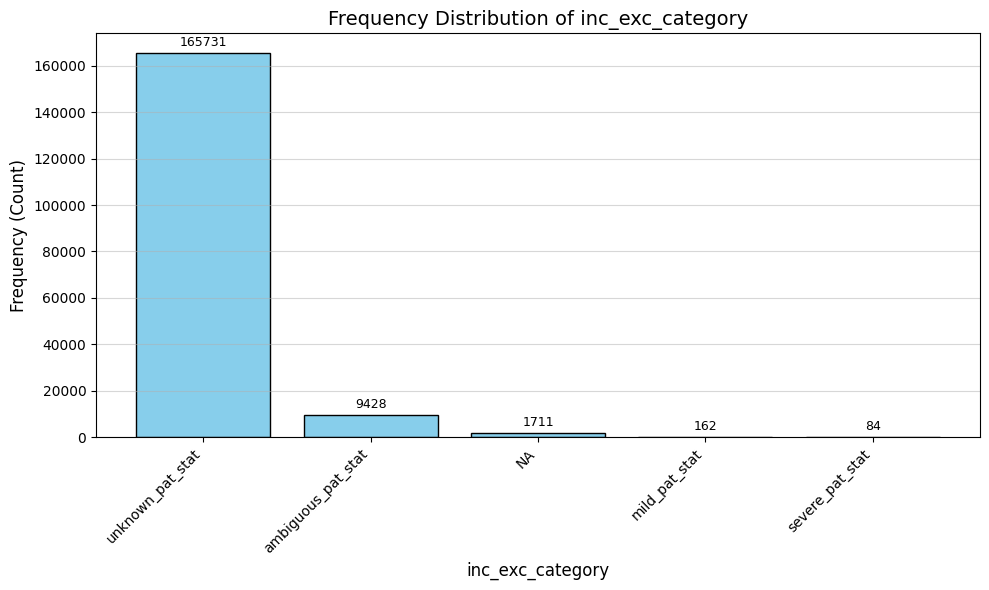

In [149]:
plot_hist(dfs[5][0], "inc_exc_category", sort_by_counts=True)

*************************** Year: 2020 ***************************


/home/asudarshan14/EpiCoV_Summer25/src/utils.py:345: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


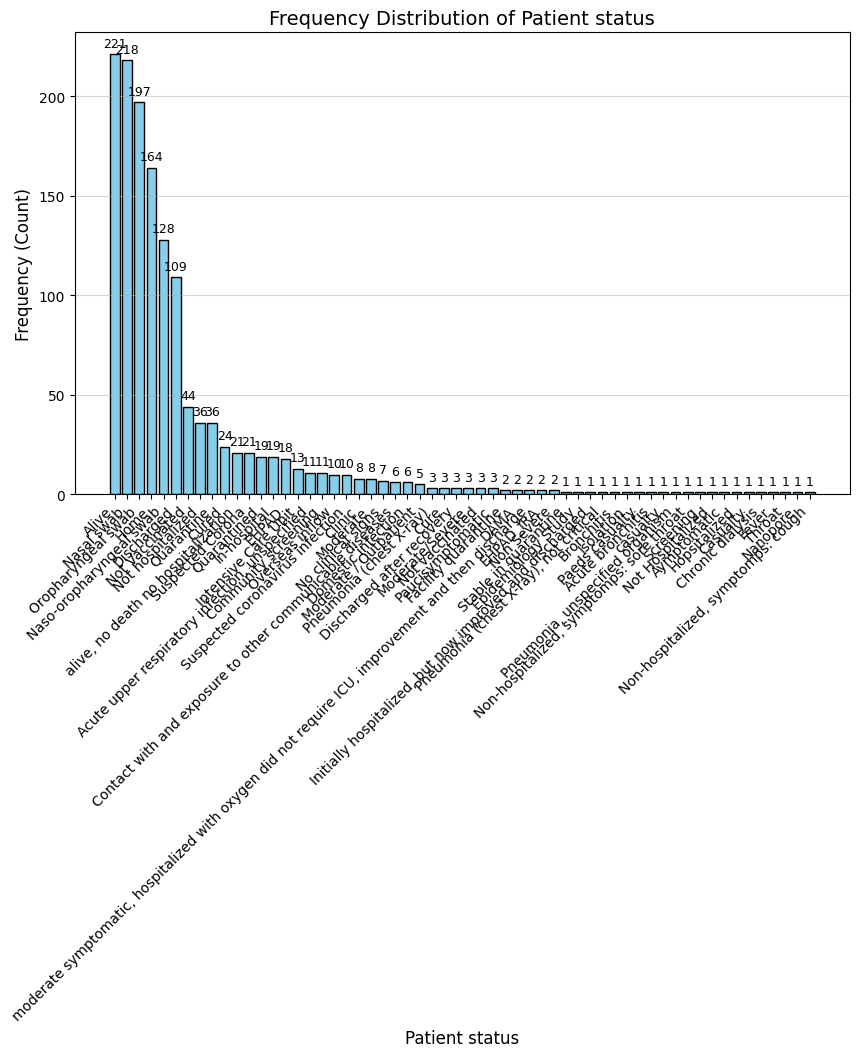

*************************** Year: 2021 ***************************


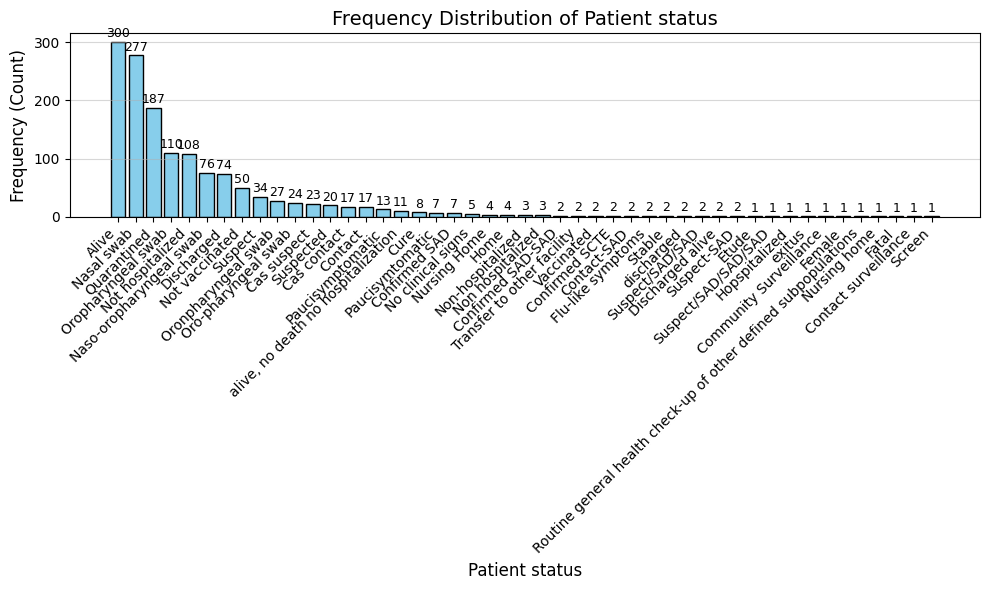

*************************** Year: 2022 ***************************


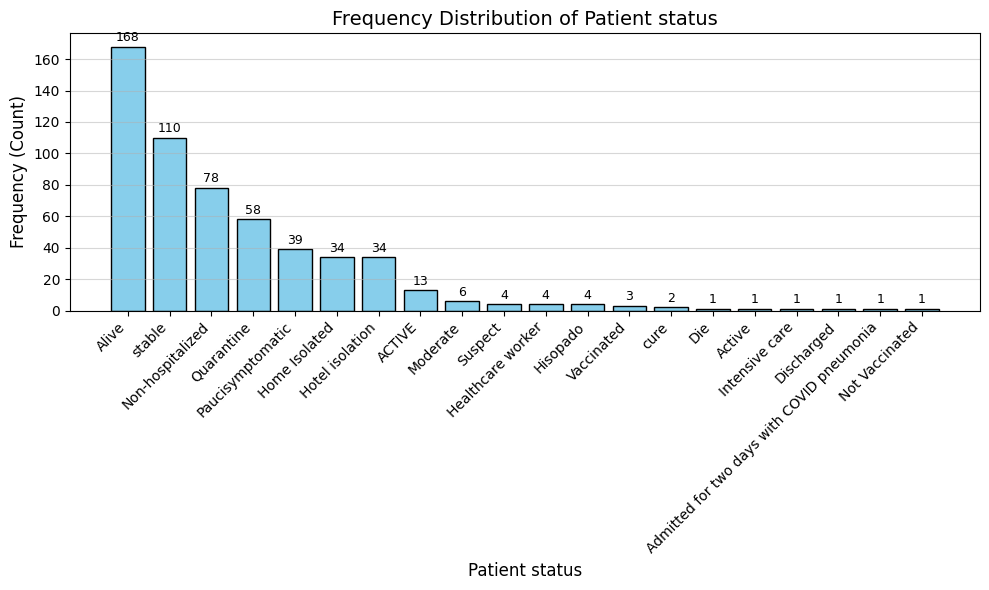

*************************** Year: 2023 ***************************


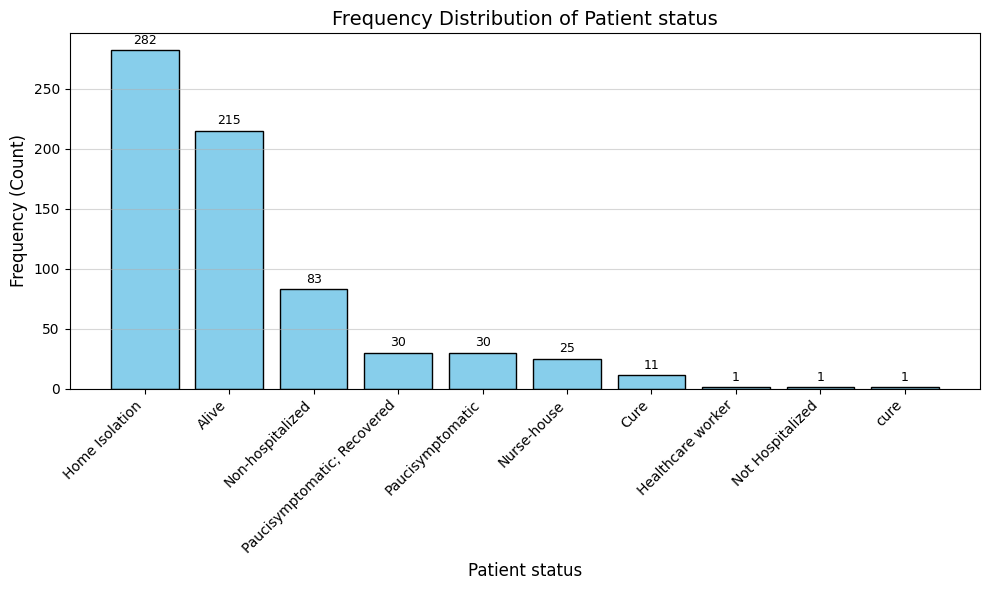

*************************** Year: 2024 ***************************


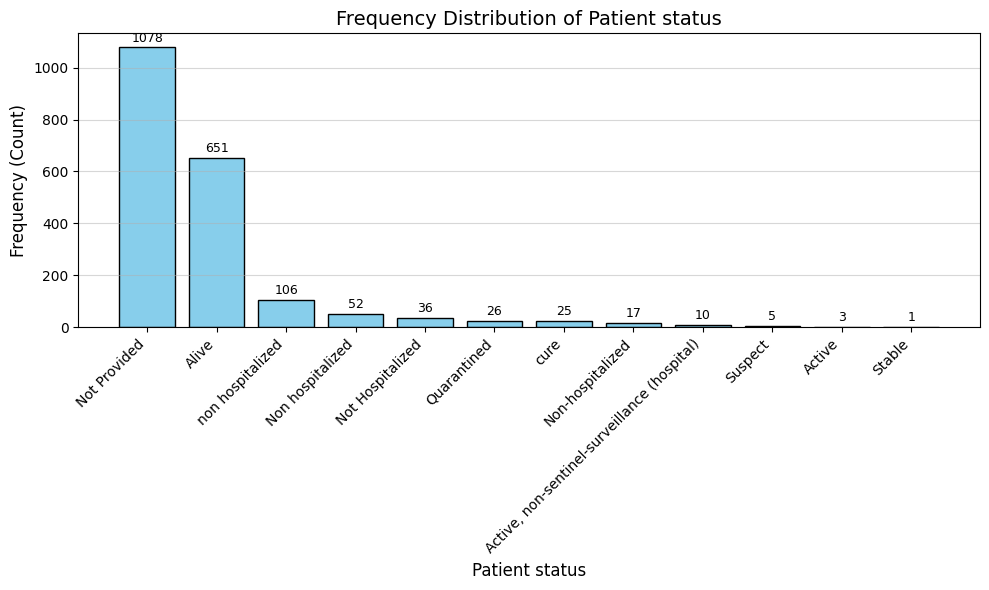

*************************** Year: 2025 ***************************


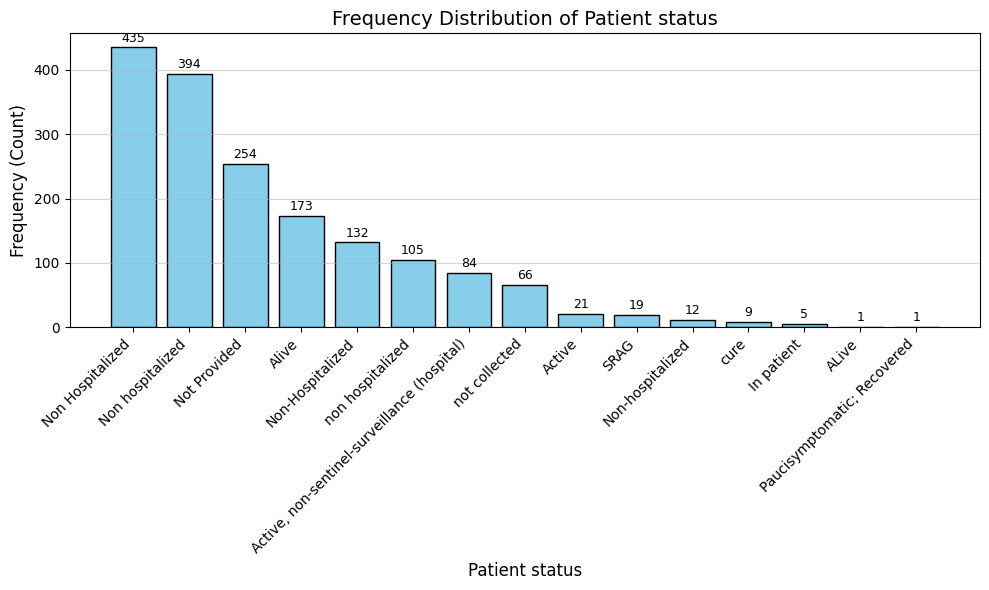

In [158]:
for yr in range(2020, 2026):
    df = dfs[yr - 2020][0]
    print(f"*************************** Year: {yr} ***************************")
    # print(sorted(df[df["inc_exc_category"]=="NA"]["Patient status"].astype(str).str.lower().unique().tolist()))
    # print([x[0] for x in list(df[df["inc_exc_category"]=="NA"]["Patient status"].astype(str).str.lower().value_counts().to_dict().items())])
    plot_hist(df[df["inc_exc_category"]=="NA"], "Patient status", sort_by_counts=True)